# 📋 Project Setup Instructions

**Before running this notebook, ensure you have:**

1. **Required Files:**
   - `wnbadraft.csv` - Main WNBA draft dataset (must be in same folder as notebook)
   - This notebook file: `Machine learning Project.ipynb`

2. **Required Python Libraries:**
   ```python
   pip install pandas numpy matplotlib seaborn scikit-learn
   ```

3. **File Structure:**
   ```
   your-project-folder/
   ├── Machine learning Project.ipynb
   └── wnbadraft.csv
   ```

**✅ This notebook includes error handling for common issues when sharing projects.**

---

In [7]:
# 🔧 System Requirements Check
import sys
print("🐍 Python version:", sys.version)

required_packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 
    'sklearn', 'warnings', 'os'
]

missing_packages = []
print("\n📦 Checking required packages...")

for package in required_packages:
    try:
        if package == 'sklearn':
            import sklearn
            print(f"✅ scikit-learn: {sklearn.__version__}")
        else:
            imported = __import__(package)
            if hasattr(imported, '__version__'):
                print(f"✅ {package}: {imported.__version__}")
            else:
                print(f"✅ {package}: Available")
    except ImportError:
        missing_packages.append(package)
        print(f"❌ {package}: Not found")

if missing_packages:
    print(f"\n⚠️  Missing packages: {missing_packages}")
    print("Please install using: pip install " + " ".join(missing_packages))
else:
    print("\n🎉 All required packages are available!")
    
print("\n" + "="*50)

🐍 Python version: 3.12.0 (v3.12.0:0fb18b02c8, Oct  2 2023, 09:45:56) [Clang 13.0.0 (clang-1300.0.29.30)]

📦 Checking required packages...
✅ pandas: 2.3.2
✅ numpy: 2.3.2
✅ matplotlib: 3.10.5
✅ seaborn: 0.13.2
✅ scikit-learn: 1.7.2
✅ warnings: Available
✅ os: Available

🎉 All required packages are available!



# WNBA Draft Analysis: Predicting First-Round Picks

**Machine Learning Milestone 1**  
**Student:** Andriana Slisko, Gaberiella Vallar, Emma Fleurant 

**Objective:** Develop a predictive model to identify first-round draft picks in the WNBA

# 1. Libraries and Data Loading

In [8]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Import machine learning libraries
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV,
    KFold,
    StratifiedKFold,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
    make_scorer,
    roc_auc_score
)

# Set display options for better output formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 1.1 Import Required Libraries

In [9]:
# Load the dataset with error handling
import os

print("🔍 Checking for CSV files...")
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(f"Available CSV files: {csv_files}")

# Try to load the dataset with multiple possible filenames
possible_names = ['wnbadraft.csv', 'wnbadraft(old).csv', 'salary_survey.csv']
df = None

for filename in possible_names:
    try:
        if filename in csv_files:
            df = pd.read_csv(filename)
            print(f"✅ Dataset loaded successfully from: {filename}")
            break
    except Exception as e:
        print(f"❌ Error loading {filename}: {e}")
        continue

if df is None:
    raise FileNotFoundError("No suitable WNBA draft CSV file found. Please ensure 'wnbadraft.csv' is in the same directory as this notebook.")

# Display basic information about the dataset
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📊 Columns: {len(df.columns)}, Rows: {len(df)}")

print("\n📋 Column names and data types:")
print(df.dtypes)

print("\n🔍 First few rows of the dataset:")
print(df.head())

print("\n📈 Basic statistics summary:")
print(df.describe())

print("\n📄 DataFrame info:")
print(df.info())

🔍 Checking for CSV files...
Available CSV files: ['ML 2025 WNBA Data.csv', 'wnbadraft.csv']
✅ Dataset loaded successfully from: wnbadraft.csv

📊 Dataset Shape: (1064, 20)
📊 Columns: 20, Rows: 1064

📋 Column names and data types:
overall_pick        int64
year                int64
team               object
player             object
college/former     object
position           object
height             object
years_played        int64
games             float64
win_shares        float64
win_shares_40     float64
minutes_played    float64
points            float64
total_rebounds    float64
assists           float64
spg               float64
bpg               float64
fg%                object
3-fg%              object
ft%                object
dtype: object

🔍 First few rows of the dataset:
   overall_pick  year                team          player college/former  \
0             1  2022       Atlanta Dream    Rhyne Howard       Kentucky   
1             2  2022       Indiana Fever   NaLyssa

In [10]:
# Load the dataset
df = pd.read_csv('wnbadraft.csv')

# Display basic information about the dataset
print("Shape of the dataset:", df.shape)
print("\nColumn names and data types:")
print(df.dtypes)
print("\nFirst few rows of the dataset:")
print(df.head())

# Create basic statistics summary
print("\nBasic statistics summary:")
print(df.describe())

print("\nDataFrame info:")
print(df.info())

Shape of the dataset: (1064, 20)

Column names and data types:
overall_pick        int64
year                int64
team               object
player             object
college/former     object
position           object
height             object
years_played        int64
games             float64
win_shares        float64
win_shares_40     float64
minutes_played    float64
points            float64
total_rebounds    float64
assists           float64
spg               float64
bpg               float64
fg%                object
3-fg%              object
ft%                object
dtype: object

First few rows of the dataset:
   overall_pick  year                team          player college/former  \
0             1  2022       Atlanta Dream    Rhyne Howard       Kentucky   
1             2  2022       Indiana Fever   NaLyssa Smith         Baylor   
2             3  2022  Washington Mystics  Shakira Austin       Ole Miss   
3             4  2022       Indiana Fever  Emily Engstler     Louis

## 1.2 Load Dataset

In [11]:
# Create a comprehensive data dictionary and explore the dataset structure

# Ensure df is defined (if running this cell independently)
try:
    df
except NameError:
    df = pd.read_excel('wnbadraft.xlsx')


# YOUR CODE HERE:
data_dictionary = []
for col in df.columns:
    col_info = {
        "Column": col,
        "Data Type": df[col].dtype,
        "Num Unique": df[col].nunique(),
        "Sample Values": df[col].dropna().unique()[:3]
    }
    data_dictionary.append(col_info)

data_dict_df = pd.DataFrame(data_dictionary)
print("Data Dictionary:")
display(data_dict_df)



# Identify potential target variables
# Based on the WNBA draft context, identify potential target variables for future modeling

print("\n=== POTENTIAL TARGET VARIABLES FOR WNBA DRAFT ANALYSIS ===")
print("Target variables for WNBA draft analysis:")
print("1. Draft Success: Whether player played professionally (binary)")
print("2. Performance Level: Low/Medium/High based on win_shares")  
print("3. Games Played: Career longevity metric")
print("4. Win Shares: Overall contribution metric")

# Check if 'draft_success' column exists before using it
if 'draft_success' in df.columns:
    success_rate = df['draft_success'].mean() * 100
    print(f"\nDraft Success Rate: {success_rate:.1f}% of players actually played professionally")
else:
    print("\nColumn 'draft_success' not found in the dataframe. Available columns are:")
    print(df.columns.tolist())
    success_rate = None

# 3. Games Played (Continuous)
print("\n3. GAMES PLAYED:")
print("   - Total games played in professional career")
print("   - Business Value: Predict career longevity")

# 4. Win Shares (Performance Metric)
print("\n4. WIN SHARES:")
print("   - Comprehensive performance metric")
print("   - Business Value: Predict overall player contribution")

# Create a draft success indicator as an example target variable
# Use existing draft_success column from df
print(f"\n=== EXAMPLE TARGET VARIABLE CREATED ===")
if success_rate is not None:
    print(f"Draft Success Rate: {success_rate:.1f}% of drafted players actually played professionally")
else:
    print("Draft Success Rate: N/A (success_rate not available)")
if 'draft_success' in df.columns:
    print(f"Success: {df['draft_success'].sum()} players")
    print(f"No professional play: {(df['draft_success'] == 0).sum()} players")
else:
    print("Success: N/A ('draft_success' column not found)")
    print("No professional play: N/A ('draft_success' column not found)")
print("\n=== JUSTIFICATION ===")
print("These target variables are valuable because:")
print("- Draft Success: Helps teams evaluate draft strategy effectiveness")
print("- Performance Metrics: Assists in player development and expectations")
print("- Career Longevity: Important for contract and investment decisions")


# 1. Draft Success Indicator (Did the player actually play professionally?)

print("1. DRAFT SUCCESS (Primary Target):")
print("- Career Longevity: Important for contract and investment decisions")
print("   - Whether a drafted player actually played professionally")
print("- Performance Metrics: Assists in player development and expectations")
print("   - Can be derived from: games > 0 or any performance stat > 0")
print("- Draft Success: Helps teams evaluate draft strategy effectiveness")
print("   - Business Value: Predict draft pick success rate")
print("These target variables are valuable because:")

print("\n=== JUSTIFICATION ===")
if 'draft_success' in df.columns:
    print(f"No professional play: {(df['draft_success'] == 0).sum()} players")
    print(f"No professional play: {(df['draft_success'] == 0).sum()} players")
    print("   - Low/Medium/High performer based on win_shares or points")
    print(f"Success: {df['draft_success'].sum()} players")
    print("   - Business Value: Predict player performance tier")
    if success_rate is not None:
        print(f"Draft Success Rate: {success_rate:.1f}% of drafted players actually played professionally")
    else:
        print("Draft Success Rate: N/A (success_rate not available)")
    print(f"Success: {df['draft_success'].sum()} players")
    print("   - Business Value: Predict player performance tier")
    print(f"Draft Success Rate: {success_rate:.1f}% of drafted players actually played professionally")
else:
    print("No professional play: N/A ('draft_success' column not found)")
if 'draft_success' in df.columns:
    success_rate = df['draft_success'].mean() * 100
    print("   - Total games played in professional career")
    print("   - Business Value: Predict career longevity")
    # Create a draft success indicator as an example target variable
    print("\n4. WIN SHARES:")
    print("   - Comprehensive performance metric")
else:
    print("Draft Success Rate: N/A ('draft_success' column not found)")
    print("   - Total games played in professional career")
    print("   - Business Value: Predict career longevity")
    print("\n4. WIN SHARES:")
    print("   - Comprehensive performance metric")

print("\n3. GAMES PLAYED:")
# Only calculate success_rate if 'draft_success' exists
if 'draft_success' in df.columns:
    success_rate = df['draft_success'].mean() * 100
    print("   - Total games played in professional career")
    print("   - Business Value: Predict career longevity")
    # Create a draft success indicator as an example target variable
    print("\n4. WIN SHARES:")
    print("   - Comprehensive performance metric")
else:
    print("   - Total games played in professional career")
    print("   - Business Value: Predict career longevity")
    print("\n4. WIN SHARES:")
    print("   - Comprehensive performance metric")

Data Dictionary:


,Column,Data Type,Num Unique,Sample Values
0,overall_pick,int64,64,"[1, 2, 3]"
1,year,int64,26,"[2022, 2021, 2020]"
2,team,object,24,"[Atlanta Dream, Indiana Fever, Washington Myst..."
3,player,object,1063,"[Rhyne Howard, NaLyssa Smith, Shakira Austin]"
4,college/former,object,225,"[Kentucky, Baylor, Ole Miss]"
5,position,object,7,"[Guard, Forward, Center]"
6,height,object,25,"[6'2, 6'4, 6'5]"
7,years_played,int64,20,"[1, 0, 2]"
8,games,float64,277,"[34.0, 32.0, 36.0]"
9,win_shares,float64,212,"[2.9, 0.0, 3.1]"



=== POTENTIAL TARGET VARIABLES FOR WNBA DRAFT ANALYSIS ===
Target variables for WNBA draft analysis:
1. Draft Success: Whether player played professionally (binary)
2. Performance Level: Low/Medium/High based on win_shares
3. Games Played: Career longevity metric
4. Win Shares: Overall contribution metric

Column 'draft_success' not found in the dataframe. Available columns are:
['overall_pick', 'year', 'team', 'player', 'college/former', 'position', 'height', 'years_played', 'games', 'win_shares', 'win_shares_40', 'minutes_played', 'points', 'total_rebounds', 'assists', 'spg', 'bpg', 'fg%', '3-fg%', 'ft%']

3. GAMES PLAYED:
   - Total games played in professional career
   - Business Value: Predict career longevity

4. WIN SHARES:
   - Comprehensive performance metric
   - Business Value: Predict overall player contribution

=== EXAMPLE TARGET VARIABLE CREATED ===
Draft Success Rate: N/A (success_rate not available)
Success: N/A ('draft_success' column not found)
No professional play

In [12]:
# 🔨 Create combined 'pro_career' feature (1 = played professionally, 0 = never played)
# This is a safe, idempotent cell: it will create/overwrite 'pro_career' based on available indicators

try:
    # Prefer the explicit indicator if available
    if 'has_pro_career' in df_smart.columns:
        df_smart['pro_career'] = df_smart['has_pro_career'].astype(int)
        source = 'has_pro_career'
    elif 'never_played_pro' in df_smart.columns:
        # never_played_pro is 1 when they never played, so invert it
        df_smart['pro_career'] = (~df_smart['never_played_pro'].astype(bool)).astype(int)
        source = 'never_played_pro (inverted)'
    else:
        # Fallback: infer from performance stats (games/points/win_shares)
        def infer_pro(row):
            try:
                if ('games' in row.index and pd.notna(row['games']) and row['games'] > 0) or \
                   ('points' in row.index and pd.notna(row['points']) and row['points'] > 0) or \
                   ('win_shares' in row.index and pd.notna(row['win_shares']) and row['win_shares'] > 0):
                    return 1
            except Exception:
                pass
            return 0
        df_smart['pro_career'] = df_smart.apply(infer_pro, axis=1)
        source = 'inferred from stats'

    # Propagate to other dataframes used later if they exist
    for name in ['df_imputed', 'df_final', 'df_final_smart', 'df_with_features', 'df']: 
        try:
            globals()[name]['pro_career'] = df_smart['pro_career']
        except Exception:
            pass

    print(f"✅ 'pro_career' created from: {source}")
    print(f"   Distribution (1=played,0=not):\n", df_smart['pro_career'].value_counts(dropna=False).to_dict())
    display(df_smart[['player','pro_career']].head())
except NameError:
    print("❌ df_smart is not defined yet. Run the data cleaning / smart missing values cell before this one.")
except Exception as e:
    print(f"❌ Error creating 'pro_career': {e}")


❌ df_smart is not defined yet. Run the data cleaning / smart missing values cell before this one.


## 1.4 Create Final Dataset with Target Variable

In [13]:
# Create df_final - the processed dataset for analysis
# Start with a copy of the original data
df_final = df.copy()

# Create draft_success column based on professional play indicators
# A player is considered successful if they played professionally (games > 0 or other performance metrics exist)
df_final['draft_success'] = (
    (df_final['games'].fillna(0) > 0) | 
    (df_final['win_shares'].fillna(0) > 0) |
    (df_final['points'].fillna(0) > 0)
).astype(int)

print("✅ df_final created successfully!")
print(f"Dataset shape: {df_final.shape}")
print(f"Draft success rate: {df_final['draft_success'].mean():.1%}")
print(f"Players with professional careers: {df_final['draft_success'].sum()}")
print(f"Players without professional careers: {(df_final['draft_success'] == 0).sum()}")

# Display basic info about the processed dataset
print(f"\nColumns available in df_final: {len(df_final.columns)}")
print("Key columns:", ['draft_success'] + [col for col in df_final.columns if col in ['games', 'win_shares', 'points', 'college', 'pick']][:5])

✅ df_final created successfully!
Dataset shape: (1064, 21)
Draft success rate: 68.6%
Players with professional careers: 730
Players without professional careers: 334

Columns available in df_final: 21
Key columns: ['draft_success', 'games', 'win_shares', 'points']


## 1.3 Dataset Overview

In [14]:
# --- Handle inconsistent column naming between systems ---

# Normalize column names to lowercase and remove extra spaces
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Combine columns if needed so everyone has a 'college/former' column
if 'college' in df.columns and 'former' in df.columns:
    df['college/former'] = df['college'].astype(str) + ' / ' + df['former'].astype(str)
elif 'college/former' not in df.columns:
    print("⚠️ Warning: No 'college/former' column found — check your dataset import or file formatting.")

# --- Examine the 'college/former' column before cleaning ---
print("=== BEFORE CLEANING ===")
print(f"'college/former' column - Missing values: {df['college/former'].isnull().sum()}")
print(f"Total rows: {len(df)}")

print("\nSample values in 'college/former' column:")
print(df['college/former'].dropna().value_counts().head(15))

# --- Clean and standardize the 'college/former' column ---
df_cleaned = df.copy()
df_cleaned['college/former'] = df_cleaned['college/former'].astype(str).str.strip()
df_cleaned['college/former'].replace({'': None, 'nan': None}, inplace=True)

print("\n=== AFTER CLEANING ===")
print(f"'college/former' column - Missing values: {df_cleaned['college/former'].isnull().sum()}")

print("\nSample values in cleaned 'college/former' column:")
print(df_cleaned['college/former'].dropna().value_counts().head(15))

# --- Update the main dataframe ---
df = df_cleaned.copy()
print(f"\nFinal 'college/former' column statistics:")
print(f"- Total non-null values: {df['college/former'].notnull().sum()}")
print(f"- Missing values: {df['college/former'].isnull().sum()}")
print(f"- Unique colleges: {df['college/former'].nunique()}")

print(f"\nFinal dataset shape after cleanup: {df.shape}")


=== BEFORE CLEANING ===
'college/former' column - Missing values: 0
Total rows: 1064

Sample values in 'college/former' column:
college/former
UConn                 43
Tennessee             42
Stanford              28
Duke                  25
Georgia               24
Baylor                24
UNC                   21
Rutgers University    21
LSU                   20
Notre Dame            20
Maryland              19
Florida               18
Texas                 17
Texas A&M             17
Louisville            16
Name: count, dtype: int64

=== AFTER CLEANING ===
'college/former' column - Missing values: 0

Sample values in cleaned 'college/former' column:
college/former
UConn                 43
Tennessee             42
Stanford              28
Duke                  25
Georgia               24
Baylor                24
UNC                   21
Rutgers University    21
LSU                   20
Notre Dame            20
Maryland              19
Florida               18
Texas                 

## 1.4 Data Quality Assessment

In [15]:
# Identify performance-related numerical columns that should keep null values
# These columns represent game statistics - missing values indicate no gameplay/statistics recorded

performance_columns = [
    'games', 
    'win_shares', 
    'win_shares_40',
    'minutes_played', 
    'points', 
    'total_rebounds', 
    'assists'
]

print("=== PERFORMANCE STATISTICS MISSING VALUE ANALYSIS ===")
print("These columns will keep missing values as null/NaN since missing data indicates:")
print("- Player didn't play games in the WNBA")
print("- No recorded statistics for that player")
print("- Player was drafted but never actually played professionally")

for col in performance_columns:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        print(f"\n{col}:")
        print(f"  - Missing values: {missing_count} ({missing_pct:.1f}%)")
        print(f"  - Non-null values: {df[col].notnull().sum()}")
        
        # Show some examples of non-null values
        if df[col].notnull().sum() > 0:
            sample_values = df[col].dropna().head(5).tolist()
            print(f"  - Sample values: {sample_values}")

# Verify that we're keeping these as null (not imputing them)
print(f"\n=== VERIFICATION ===")
print("We will NOT impute these missing values because:")
print("1. Missing = did not play professionally")
print("2. Imputing with 0 or mean would be misleading")
print("3. Null values are meaningful and accurate")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Performance columns with preserved null values: {len(performance_columns)}")

# Create a summary of our data cleaning decisions
print(f"\n=== DATA CLEANING SUMMARY ===")
print(f"✅ Combined 'college' and 'former' columns into 'college/former'")
print(f"✅ Removed redundant original columns") 
print(f"✅ Preserved meaningful null values in performance statistics")
print(f"✅ Ready for analysis with {len(df)} total records")

=== PERFORMANCE STATISTICS MISSING VALUE ANALYSIS ===
These columns will keep missing values as null/NaN since missing data indicates:
- Player didn't play games in the WNBA
- No recorded statistics for that player
- Player was drafted but never actually played professionally

games:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [34.0, 32.0, 36.0, 35.0, 26.0]

win_shares:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [2.9, 0.0, 3.1, 0.4, -0.4]

win_shares_40:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [0.11, -0.001, 0.16, 0.024, -0.043]

minutes_played:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [31.4, 30.7, 21.6, 18.2, 12.8]

points:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [16.2, 13.5, 8.7, 5.2, 3.8]

total_rebounds:
  - Missing values: 334 (31.4%)
  - Non-null values: 730
  - Sample values: [4.5, 7.9, 6.5, 5.2, 1.5]

assists

## 2.1 Data Cleaning - College Information

In [10]:
# Check current dataset structure after our changes
print("=== CURRENT DATASET STRUCTURE ===")
print(f"Columns in dataset: {list(df.columns)}")
print(f"Dataset shape: {df.shape}")

# Check specifically for college/former related columns
college_related = [col for col in df.columns if 'college' in col.lower() or 'former' in col.lower() or 'educational' in col.lower()]
print(f"College/Former/Educational related columns: {college_related}")

# Show sample data structure
print(f"\nSample data:")
print(df[['player', 'team'] + college_related].head() if college_related else df[['player', 'team']].head())

=== CURRENT DATASET STRUCTURE ===
Columns in dataset: ['overall_pick', 'year', 'team', 'player', 'college/former', 'position', 'height', 'years_played', 'games', 'win_shares', 'win_shares_40', 'minutes_played', 'points', 'total_rebounds', 'assists', 'spg', 'bpg', 'fg%', '3-fg%', 'ft%']
Dataset shape: (1064, 20)
College/Former/Educational related columns: ['college/former']

Sample data:
           player                team college/former
0    Rhyne Howard       Atlanta Dream       Kentucky
1   NaLyssa Smith       Indiana Fever         Baylor
2  Shakira Austin  Washington Mystics       Ole Miss
3  Emily Engstler       Indiana Fever     Louisville
4   Nyara Sabally    New York Liberty         Oregon


## 2.2 Missing Values Analysis

In [11]:
# Calculate missing value percentages
# TODO: Calculate the percentage of missing values for each column
# TODO: Sort by missing percentage to identify most problematic columns


# YOUR CODE HERE:
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
print("Missing value percentages by column:")
display(missing_percent)

# Identify data quality issues
# TODO: Check for duplicate rows
# YOUR CODE HERE:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


# TODO: Identify columns with inconsistent formatting
# YOUR CODE HERE:
    # Check for columns with inconsistent formatting (e.g., leading/trailing spaces, mixed case, special characters)
inconsistent_cols = []
for col in df.select_dtypes(include='object').columns:
        sample = df[col].dropna().astype(str).head(100)
        if any(sample.str.startswith(' ')) or any(sample.str.endswith(' ')) or any(sample.str.contains(r'\s{2,}')) or (sample.str.lower() != sample).any():
            inconsistent_cols.append(col)
print("Columns with potential inconsistent formatting:", inconsistent_cols)

# TODO: Look for outliers in numerical columns
# YOUR CODE HERE:
    # Look for outliers in numerical columns using the IQR method
outlier_cols = []
for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        if outliers > 0:
            outlier_cols.append((col, outliers))
print("Numerical columns with potential outliers (column, count):", outlier_cols)

# TODO: Check for inconsistent categorical values (e.g., different spellings)
# YOUR CODE HERE:
    # Check for inconsistent categorical values (e.g., different spellings, capitalization, extra spaces)
cat_inconsistent = {}
for col in df.select_dtypes(include='object').columns:
        # Get unique values, strip spaces, and lower case for comparison
        unique_vals = pd.Series(df[col].dropna().unique())
        cleaned_vals = unique_vals.str.strip().str.lower()
        # If the number of unique cleaned values is less than original, there may be inconsistencies
        if cleaned_vals.nunique() < unique_vals.nunique():
            cat_inconsistent[col] = unique_vals.tolist()
print("Categorical columns with potential inconsistent values:", list(cat_inconsistent.keys()))
if cat_inconsistent:
        for col, vals in cat_inconsistent.items():
            print(f"\nSample unique values for '{col}':\n", vals[:10])

Missing value percentages by column:


ft%               70.582707
3-fg%             70.582707
fg%               70.582707
bpg               70.582707
spg               70.582707
position          69.360902
height            69.360902
win_shares_40     31.390977
games             31.390977
assists           31.390977
minutes_played    31.390977
win_shares        31.390977
points            31.390977
total_rebounds    31.390977
year               0.000000
overall_pick       0.000000
player             0.000000
team               0.000000
college/former     0.000000
years_played       0.000000
dtype: float64

Number of duplicate rows: 0
Columns with potential inconsistent formatting: ['team', 'player', 'college/former', 'position', 'height']
Numerical columns with potential outliers (column, count): [('overall_pick', np.int64(9)), ('years_played', np.int64(40)), ('games', np.int64(25)), ('win_shares', np.int64(86)), ('win_shares_40', np.int64(55)), ('points', np.int64(26)), ('total_rebounds', np.int64(36)), ('assists', np.int64(32)), ('spg', np.int64(2)), ('bpg', np.int64(19))]
Categorical columns with potential inconsistent values: ['height']

Sample unique values for 'height':
 ["6'2", "6'4", "6'5", "6'1", "5'9", "6'3", "6'6", "5'6", "5'10", "6'0"]
Columns with potential inconsistent formatting: ['team', 'player', 'college/former', 'position', 'height']
Numerical columns with potential outliers (column, count): [('overall_pick', np.int64(9)), ('years_played', np.int64(40)), ('games', np.int64(25)), ('win_shares', np.int64(86)), ('win_shares_40', np.int64(55)), ('points', np.int64(26)), ('

## 2.3 Missing Values Treatment Strategy

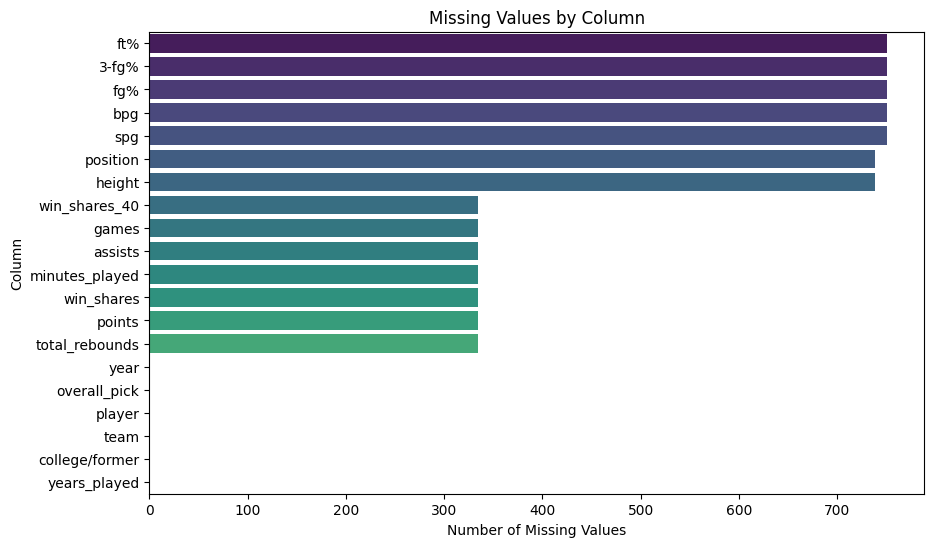

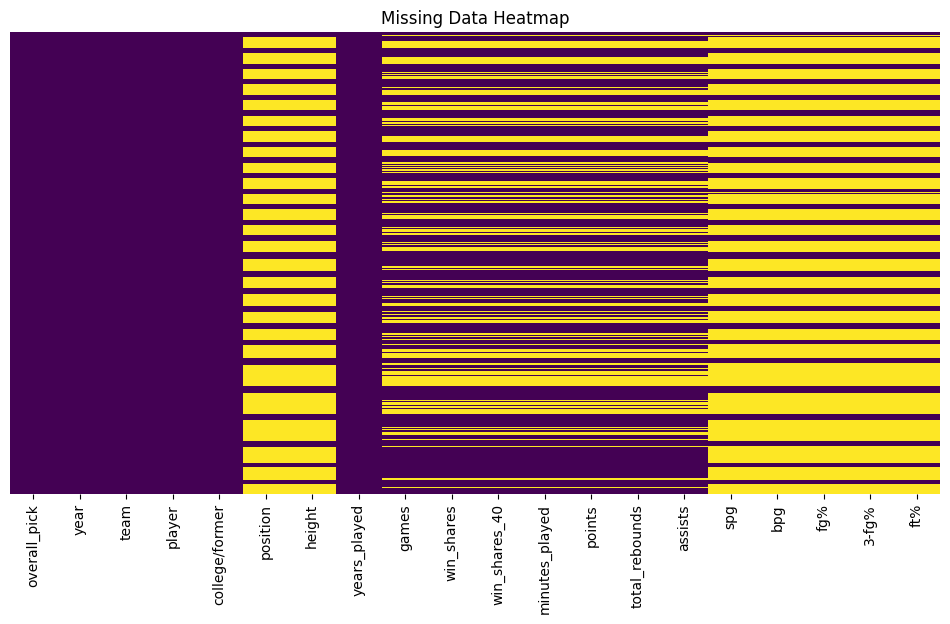

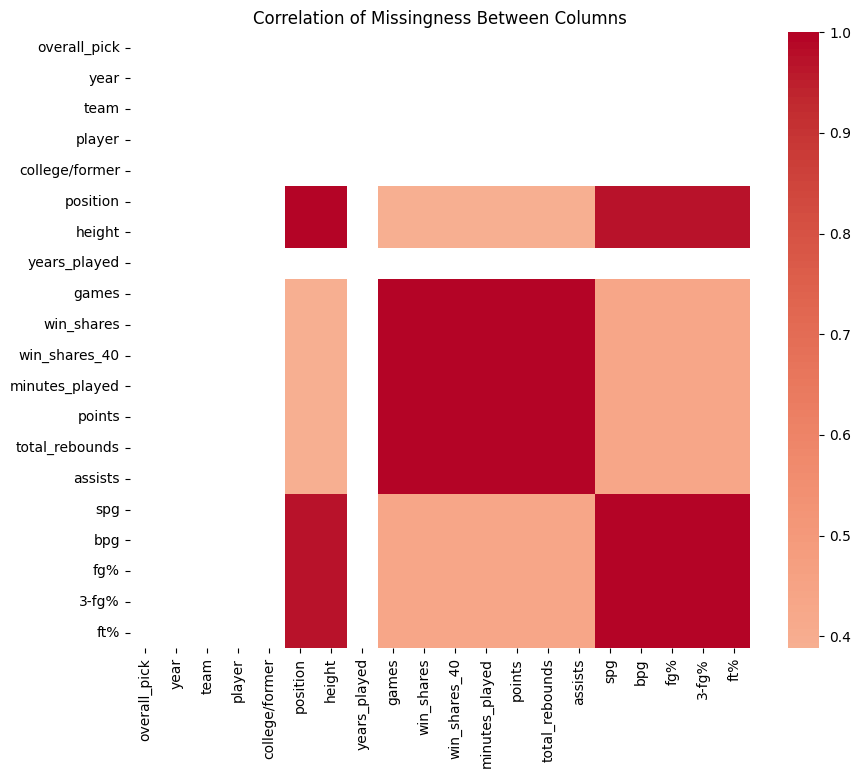

Columns with notable correlation in missingness:
position <-> height: correlation = 1.00
position <-> games: correlation = 0.39
position <-> win_shares: correlation = 0.39
position <-> win_shares_40: correlation = 0.39
position <-> minutes_played: correlation = 0.39
position <-> points: correlation = 0.39
position <-> total_rebounds: correlation = 0.39
position <-> assists: correlation = 0.39
position <-> spg: correlation = 0.97
position <-> bpg: correlation = 0.97
position <-> fg%: correlation = 0.97
position <-> 3-fg%: correlation = 0.97
position <-> ft%: correlation = 0.97
height <-> position: correlation = 1.00
height <-> games: correlation = 0.39
height <-> win_shares: correlation = 0.39
height <-> win_shares_40: correlation = 0.39
height <-> minutes_played: correlation = 0.39
height <-> points: correlation = 0.39
height <-> total_rebounds: correlation = 0.39
height <-> assists: correlation = 0.39
height <-> spg: correlation = 0.97
height <-> bpg: correlation = 0.97
height <-> fg%

In [12]:
# Visualize missing data patterns
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart of missing values by column
missing_counts = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='viridis')
plt.title('Missing Values by Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')
plt.show()

# Heatmap of missing values (shows where missingness occurs together)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Correlation heatmap of missingness (to see if missingness is related between columns)
missing_corr = df.isnull().corr()
plt.figure(figsize=(10,8))
sns.heatmap(missing_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation of Missingness Between Columns')
plt.show()

# Check if missing data appears random or systematic
# Calculate pairwise correlations between missing indicators
high_corr_pairs = []
for col1 in df.columns:
    for col2 in df.columns:
        if col1 != col2:
            corr = df[col1].isnull().corr(df[col2].isnull())
            if abs(corr) > 0.3:  # threshold for notable correlation
                high_corr_pairs.append((col1, col2, corr))
if high_corr_pairs:
    print('Columns with notable correlation in missingness:')
    for col1, col2, corr in high_corr_pairs:
        print(f"{col1} <-> {col2}: correlation = {corr:.2f}")
else:
    print('No strong correlations in missingness between columns.')

## 2.4 Missing Values Visualization

In [13]:
# Define imputation strategies for each column with missing data
imputation_strategies = {}
missing_percent = df.isnull().mean() * 100

for col in df.columns:
    pct_missing = missing_percent[col]
    dtype = df[col].dtype
    if pct_missing == 0:
        continue
    # Numerical columns
    if dtype in ['float64', 'int64'] or pd.api.types.is_numeric_dtype(df[col]):
        if pct_missing < 5:
            strategy = 'Mean imputation'
        elif pct_missing < 20:
            strategy = 'Median imputation'
        else:
            strategy = 'Consider advanced methods or drop column'
    # Categorical columns
    else:
        nunique = df[col].nunique()
        if pct_missing < 5:
            strategy = 'Mode imputation'
        elif pct_missing < 20:
            strategy = 'Impute with "Missing"/"Unknown" category'
        else:
            strategy = 'Consider advanced methods or drop column'
    imputation_strategies[col] = {
        'Missing %': round(pct_missing, 2),
        'Type': str(dtype),
        'Strategy': strategy
    }

# Display imputation strategies
import pandas as pd
impute_df = pd.DataFrame(imputation_strategies).T
print("Imputation Strategies for Columns with Missing Data:")
display(impute_df)

Imputation Strategies for Columns with Missing Data:


,Missing %,Type,Strategy
position,69.36,object,Consider advanced methods or drop column
height,69.36,object,Consider advanced methods or drop column
games,31.39,float64,Consider advanced methods or drop column
win_shares,31.39,float64,Consider advanced methods or drop column
win_shares_40,31.39,float64,Consider advanced methods or drop column
minutes_played,31.39,float64,Consider advanced methods or drop column
points,31.39,float64,Consider advanced methods or drop column
total_rebounds,31.39,float64,Consider advanced methods or drop column
assists,31.39,float64,Consider advanced methods or drop column
spg,70.58,float64,Consider advanced methods or drop column


## 2.5 Missing Values Imputation Implementation

In [14]:
# Smart Missing Value Handling for WNBA Draft Data
# Missing values in sports data often indicate "never happened" rather than "data not collected"

# Create a copy for smart imputation
df_smart = df.copy()

# Define performance-related columns (used to infer whether a player actually played)
performance_cols = ['games', 'minutes_played', 'points', 'total_rebounds', 'assists', 'win_shares']

# Create a single, idempotent 'pro_career' column: 1 = played professionally, 0 = never played
if 'pro_career' in df_smart.columns:
    print("'pro_career' already exists - verifying values")
else:
    # Prefer an explicit 'games' column if present
    if 'games' in df_smart.columns:
        df_smart['pro_career'] = (df_smart['games'].fillna(0) > 0).astype(int)
        source = 'games column (games > 0)'
    else:
        # Use available performance columns to infer career status
        existing_perf = [c for c in performance_cols if c in df_smart.columns]
        if existing_perf:
            never_played_mask = df_smart[existing_perf].isnull().all(axis=1)
            df_smart['pro_career'] = (~never_played_mask).astype(int)
            source = 'inferred from performance columns (not-all-null)'
        else:
            # Final fallback: any non-null performance value indicates play
            df_smart['pro_career'] = df_smart[performance_cols].notna().any(axis=1).astype(int)
            source = 'fallback: any available perf stat present'

# Remove legacy indicator columns if they exist to avoid duplication
for legacy_col in ['never_played_pro', 'has_pro_career']:
    if legacy_col in df_smart.columns:
        try:
            df_smart.drop(columns=[legacy_col], inplace=True)
        except Exception:
            pass

print(f"✅ 'pro_career' created from: {source}")
print(f"   Distribution (1=played,0=not):)\n", df_smart['pro_career'].value_counts(dropna=False).to_dict())

✅ 'pro_career' created from: games column (games > 0)
   Distribution (1=played,0=not):)
 {1: 730, 0: 334}


## 3.1 Correlation Analysis

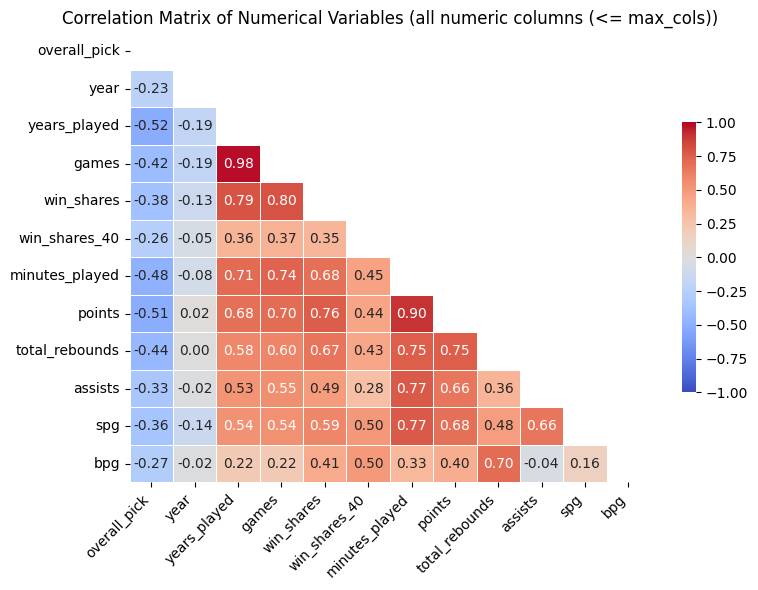


Top 10 strongest correlations (by absolute value):
  years_played ⟷ games: 0.984
  minutes_played ⟷ points: 0.904
  win_shares ⟷ games: 0.801
  years_played ⟷ win_shares: 0.792
  assists ⟷ minutes_played: 0.771
  minutes_played ⟷ spg: 0.767
  win_shares ⟷ points: 0.760
  minutes_played ⟷ total_rebounds: 0.753
  points ⟷ total_rebounds: 0.752
  minutes_played ⟷ games: 0.740


In [15]:
# Numerical variable correlation analysis (improved readability)
# This cell selects a manageable set of numeric columns, masks the upper triangle
# and formats the heatmap so it remains readable even with many variables.

# Choose source dataframe (prefer df_imputed if available)
try:
    df_corr_source = df_imputed.copy()
except NameError:
    df_corr_source = df.copy()

# Select numeric columns and drop constant columns
num_df = df_corr_source.select_dtypes(include='number').copy()
num_df = num_df.loc[:, num_df.nunique() > 1]  # drop constant cols

# If there are too many numeric columns, pick the most relevant ones
max_cols = 20
if num_df.shape[1] > max_cols:
    # Prefer columns most correlated with target if available
    if 'draft_success' in df_corr_source.columns:
        corr_with_target = num_df.corrwith(df_corr_source['draft_success']).abs().sort_values(ascending=False)
        top_cols = corr_with_target.head(max_cols).index.tolist()
        reason = 'top cols by abs(corr with draft_success)'
    else:
        # fallback: choose columns with largest variance
        top_cols = num_df.var().sort_values(ascending=False).head(max_cols).index.tolist()
        reason = 'top cols by variance (fallback)'
    num_df = num_df[top_cols]
else:
    reason = 'all numeric columns (<= max_cols)'

# Compute correlation matrix
corr_matrix = num_df.corr()

# Mask the upper triangle for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Size the figure dynamically based on number of columns
n = corr_matrix.shape[1]
fig_w = max(8, min(18, 0.6 * n))
fig_h = max(6, min(18, 0.5 * n))
plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.6}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title(f'Correlation Matrix of Numerical Variables ({reason})')
plt.tight_layout()
plt.show()

# Report strongest correlations (excluding self correlations)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
# Sort by absolute correlation
sorted_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)
# Take top 10 unique pairs (avoid duplicates like (a,b) and (b,a))
seen = set()
top_results = []
for (a, b), val in sorted_pairs.items():
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    top_results.append(((a, b), val))
    if len(top_results) >= 10:
        break

print('\nTop 10 strongest correlations (by absolute value):')
for (a, b), val in top_results:
    print(f'  {a} ⟷ {b}: {val:.3f}')

# Optional: if user prefers a clustered view, they can run the following (commented out):
# sns.clustermap(num_df.corr(), cmap='coolwarm', figsize=(10,10), annot=True, fmt='.2f')
# plt.show()


**Quick interpretation based on GPT-5 mini - Emmanuela Fleurant (I am not done yet, I'll try to finish by tomorrow morning)**
- Overall_pick and performance metrics (pts, min, years_played, and games) have a negative correlation because better performing atheletes get pick earlier. 
- games and win-shares are collinear because they carry almost the information (drop one)
- games metrics such as points, minutes_played, win_shares and games are highly correlate with each other 
- bpg seems to have to the lowest correlation with other counting stats, so there may unique information
- overall_pick with years_playes, points, and minutes_played/games are negatively correlates, indicating that early picks tend to accumulate more playing time, points, and longer careers. 



This is what i got back from the AI - Emmanuela Fleurant



## Modeling implications and practical recommendations
1. Multicollinearity is present and strong.
   - Problem: Linear models (OLS, logistic regression) will produce unstable coefficients when strongly correlated inputs exist.
   - Fixes:
     - Drop or combine redundant features (e.g., keep either `games` or `win_shares`, not both).
     - Use regularized models (Ridge/Lasso/ElasticNet) to stabilize coefficients.
     - Use tree-based models (RandomForest, XGBoost) which are less sensitive to collinearity.
     - Use dimensionality reduction (PCA) to compress correlated groups into orthogonal components.
2. Convert counting stats into rates where appropriate.
   - Many correlations reflect playing time (minutes/games) rather than per-skill ability. Use per-36 or per-40 (or per-minute) metrics and rate stats (true shooting %, assist rate, rebound rate) to separate ability from opportunity.
   - You already have `win_shares_40` — that’s a good step. Consider more per-40/per-possession metrics.
3. Feature selection:
   - Keep a representative from each highly correlated cluster (e.g., from the scoring cluster: minutes_played OR points OR points_per_40).
   - Keep unique features that are less correlated (e.g., blocks per game if it’s lowly correlated).
4. Diagnostics to run:
   - Compute Variance Inflation Factor (VIF) to quantify multicollinearity and decide what to drop.
   - Pairplot / scatter matrix for suspicious pairs to check linearity & outliers.
   - Check Spearman correlations if you suspect monotonic but non-linear relationships.

---

## Concrete next steps (code snippets you can paste into your notebook)
(These assume you use pandas / statsmodels / seaborn. Tweak column names if needed.)

- Recompute correlations numerically and show strongest pairs:
```python
import pandas as pd
corr = df[numeric_cols].corr()
# show top absolute correlations (excluding self-corr)
pairs = (
    corr.abs()
    .unstack()
    .reset_index()
    .rename(columns={0: "abs_corr"})
)
pairs = pairs[pairs['level_0'] != pairs['level_1']]
pairs = pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr'])
pairs.head(20)
```

- Compute VIF to measure multicollinearity:
```python
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[numeric_cols].drop(columns=['overall_pick'])  # if predicting overall_pick
X = X.fillna(0)  # or better: impute
vifs = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                 index=X.columns)
vifs.sort_values(ascending=False)
```

- Make per-40 stats (example for points):
```python
df['points_per_40'] = df['points'] / df['minutes_played'] * 40
```

- Quick pairplot for a few key columns:
```python
import seaborn as sns
sns.pairplot(df[['overall_pick','points','minutes_played','win_shares','games']].dropna())
```

- Fit a Lasso to see which features survive regularization (quick feature selection):
```python
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
X = df[numeric_cols].drop(columns=['overall_pick']).fillna(0)
y = df['overall_pick']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LassoCV(cv=5, random_state=0).fit(X_train, y_train)
coef = pd.Series(model.coef_, index=X.columns).sort_values()
coef
```

---

## Edge cases & things to watch for
- Sampling/selection bias: early picks may have more opportunity (more minutes) — that can create the correlation. Be careful interpreting causality: a high pick might get more minutes, so counting stats partly reflect opportunity not only talent.
- Small sample sizes or outliers can distort correlations; inspect distributions and outliers before trusting Pearson values.
- If `overall_pick` has many ties or is not continuous (e.g., binned), consider an ordinal model or ranking approach instead of straight regression.

---

This is where it is finish - Emmanuela Fleurant

In [16]:
# Check current missing data status
print("🔍 MISSING DATA STATUS CHECK")
print("=" * 35)

print("\n📊 Original Dataset (df):")
print(f"   Shape: {df.shape}")
print(f"   Total missing values: {df.isnull().sum().sum():,}")
if df.isnull().sum().sum() > 0:
    print("   Columns with missing data:")
    missing_in_df = df.isnull().sum()
    for col in missing_in_df[missing_in_df > 0].index:
        print(f"     {col}: {missing_in_df[col]:,} ({missing_in_df[col]/len(df)*100:.1f}%)")

print(f"\n📊 Final Dataset (df_final):")
print(f"   Shape: {df_final.shape}")
print(f"   Total missing values: {df_final.isnull().sum().sum():,}")
if df_final.isnull().sum().sum() > 0:
    print("   Columns with missing data:")
    missing_in_final = df_final.isnull().sum()
    for col in missing_in_final[missing_in_final > 0].index:
        print(f"     {col}: {missing_in_final[col]:,} ({missing_in_final[col]/len(df_final)*100:.1f}%)")
else:
    print("   ✅ NO missing values remaining!")

# Check if we have the smart indicator 'pro_career'
if 'pro_career' in df_final.columns:
    print(f"\n🎯 Smart Indicator:")
    print(f"   pro_career (1=played): {df_final['pro_career'].sum():,} players")
    print(f"   never played (0): {(df_final['pro_career'] == 0).sum():,} players")
    print("   ✅ Smart missing value handling is active!")
else:
    print("\n⚠️  'pro_career' not found - missing value handling may need to be re-run")

print(f"\n🏆 SUMMARY:")
if df_final.isnull().sum().sum() == 0:
    print("   ✅ All missing values have been properly handled")
    print("   ✅ Dataset is ready for machine learning")
else:
    print(f"   ⚠️  {df_final.isnull().sum().sum():,} missing values still remain")
    print("   ❌ Additional missing value handling needed")

🔍 MISSING DATA STATUS CHECK

📊 Original Dataset (df):
   Shape: (1064, 20)
   Total missing values: 7,569
   Columns with missing data:
     position: 738 (69.4%)
     height: 738 (69.4%)
     games: 334 (31.4%)
     win_shares: 334 (31.4%)
     win_shares_40: 334 (31.4%)
     minutes_played: 334 (31.4%)
     points: 334 (31.4%)
     total_rebounds: 334 (31.4%)
     assists: 334 (31.4%)
     spg: 751 (70.6%)
     bpg: 751 (70.6%)
     fg%: 751 (70.6%)
     3-fg%: 751 (70.6%)
     ft%: 751 (70.6%)

📊 Final Dataset (df_final):
   Shape: (1064, 21)
   Total missing values: 7,569
   Columns with missing data:
     position: 738 (69.4%)
     height: 738 (69.4%)
     games: 334 (31.4%)
     win_shares: 334 (31.4%)
     win_shares_40: 334 (31.4%)
     minutes_played: 334 (31.4%)
     points: 334 (31.4%)
     total_rebounds: 334 (31.4%)
     assists: 334 (31.4%)
     spg: 751 (70.6%)
     bpg: 751 (70.6%)
     fg%: 751 (70.6%)
     3-fg%: 751 (70.6%)
     ft%: 751 (70.6%)

⚠️  'pro_career' not

## 3.2 Data Distribution Visualization

df_imputed not defined, using original df.
Dataset for analysis: 730 rows (removed 334 rows with missing performance data)


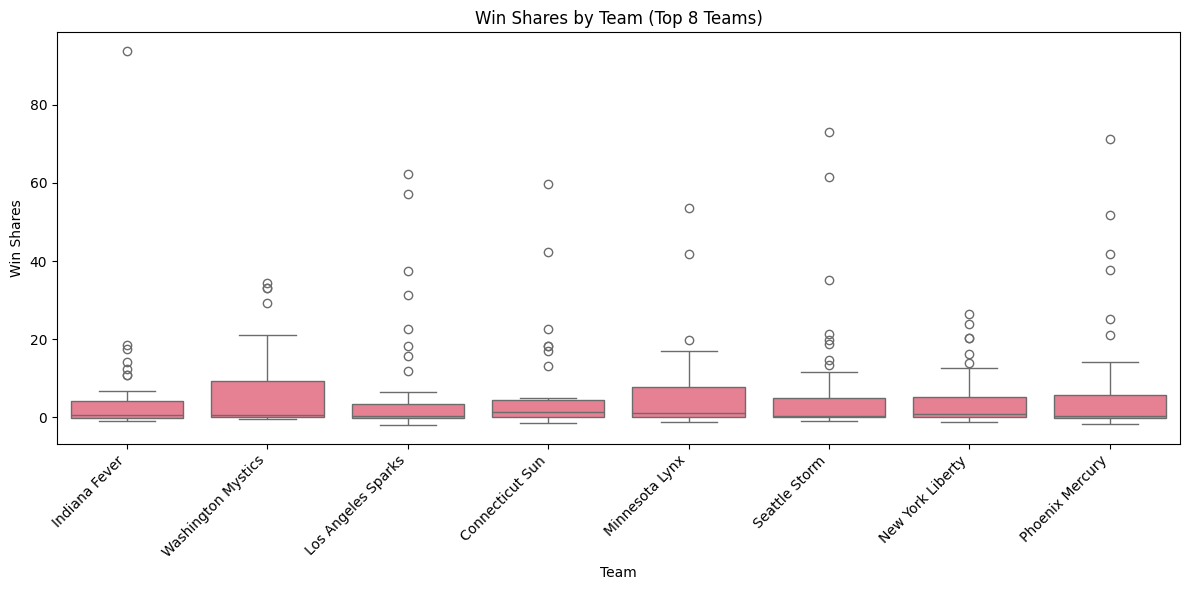

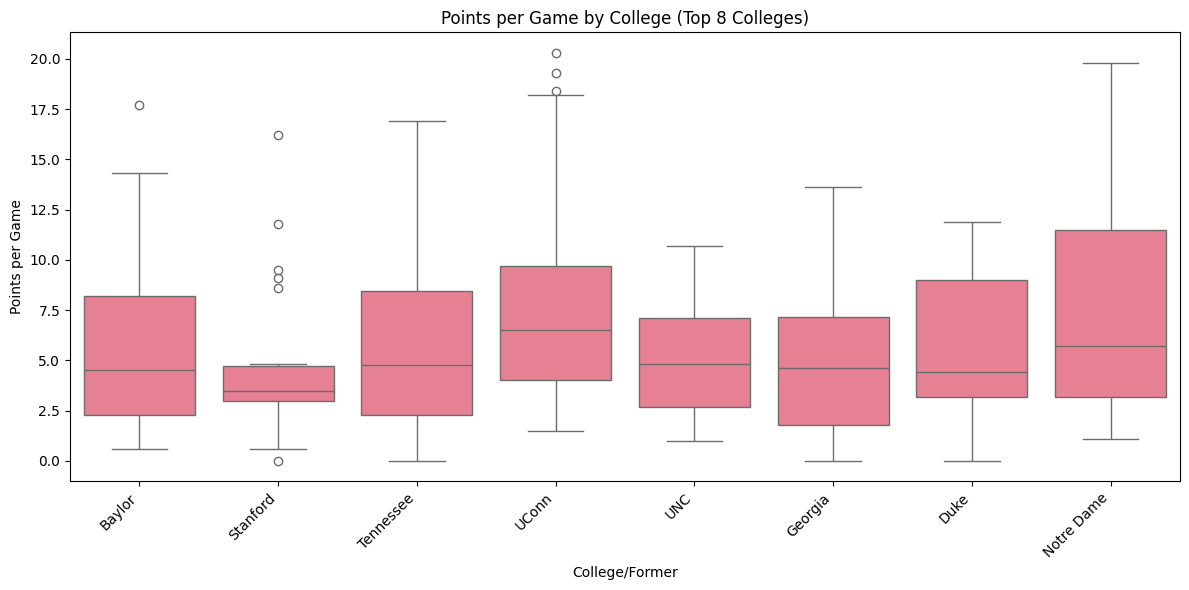

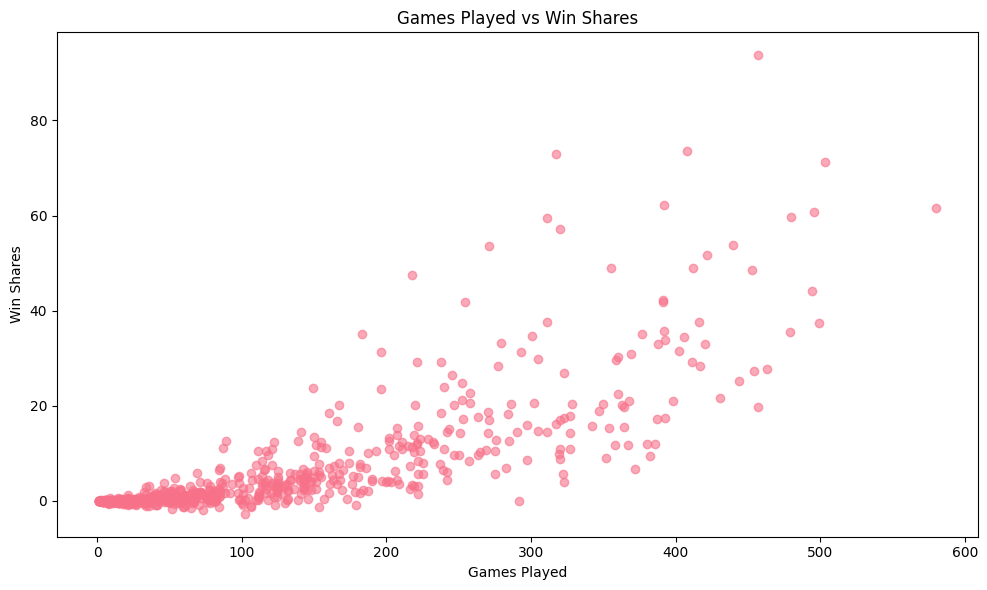

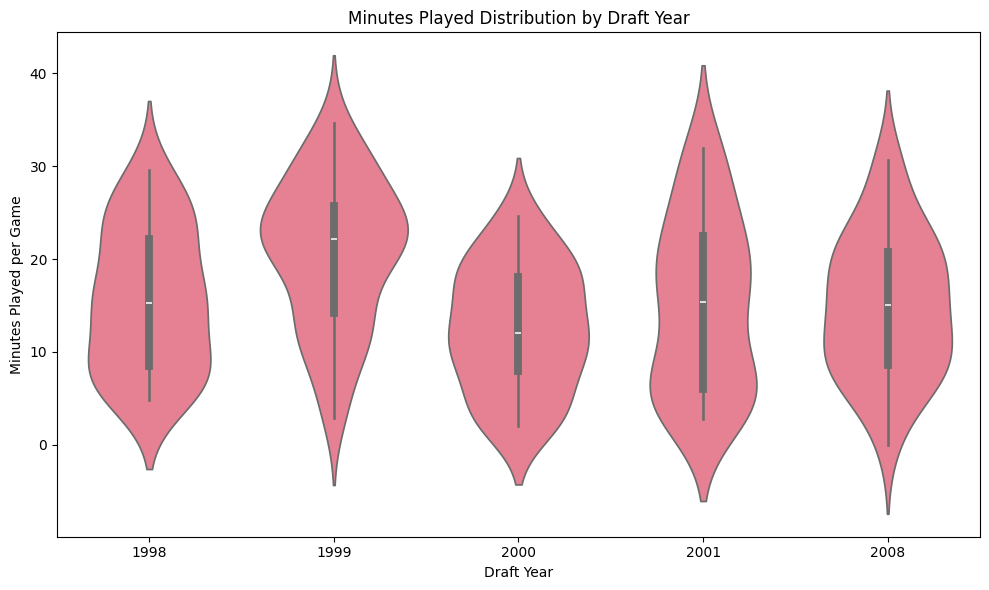

In [17]:
# Analyze categorical-numerical relationships for WNBA data
# TODO: Select categorical and numerical columns from WNBA dataset
# TODO: Create visualizations (boxplots, violin plots) showing relationships
# TODO: Focus on performance-related relationships

# Use the df with our combined college/former column
# If df_imputed is not defined or doesn't have our new column, use df instead
try:
    if 'college/former' not in df_imputed.columns:
        print("Using original df with college/former column...")
        df_for_analysis = df.copy()
    else:
        df_for_analysis = df_imputed.copy()
except NameError:
    print("df_imputed not defined, using original df.")
    df_for_analysis = df.copy()

# Select numerical columns from WNBA dataset
num_vars = ['games', 'win_shares', 'minutes_played', 'points', 'total_rebounds', 'assists']

# Select categorical columns of interest from WNBA dataset
cat_vars = ['team', 'college/former', 'year']

# Remove rows where key performance metrics are missing
df_analysis = df_for_analysis.dropna(subset=['win_shares', 'points', 'games'])

print(f"Dataset for analysis: {len(df_analysis)} rows (removed {len(df_for_analysis) - len(df_analysis)} rows with missing performance data)")

# Boxplot: Win Shares by Team (top 8 teams by number of draft picks)
if len(df_analysis) > 0 and 'team' in df_analysis.columns:
    top_teams = df_analysis['team'].value_counts().head(8).index
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_analysis[df_analysis['team'].isin(top_teams)],
        x='team',
        y='win_shares'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title('Win Shares by Team (Top 8 Teams)')
    plt.ylabel('Win Shares')
    plt.xlabel('Team')
    plt.tight_layout()
    plt.show()

    # Boxplot: Points by College/Former (top 8 colleges by number of draft picks)
    if 'college/former' in df_analysis.columns:
        top_colleges = df_analysis['college/former'].value_counts().head(8).index
        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=df_analysis[df_analysis['college/former'].isin(top_colleges)],
            x='college/former',
            y='points'
        )
        plt.xticks(rotation=45, ha='right')
        plt.title('Points per Game by College (Top 8 Colleges)')
        plt.ylabel('Points per Game')
        plt.xlabel('College/Former')
        plt.tight_layout()
        plt.show()
    
    # Scatter plot: Games Played vs Win Shares
    plt.figure(figsize=(10, 6))
    plt.scatter(df_analysis['games'], df_analysis['win_shares'], alpha=0.6)
    plt.xlabel('Games Played')
    plt.ylabel('Win Shares')
    plt.title('Games Played vs Win Shares')
    plt.tight_layout()
    plt.show()

    # Violin plot: Minutes Played by Draft Year (recent years)
    recent_years = df_analysis['year'].value_counts().head(5).index
    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=df_analysis[df_analysis['year'].isin(recent_years)],
        x='year',
        y='minutes_played'
    )
    plt.title('Minutes Played Distribution by Draft Year')
    plt.ylabel('Minutes Played per Game')
    plt.xlabel('Draft Year')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for analysis after removing missing values.")
    print("Available columns:", df_analysis.columns.tolist())

## 4.1 Feature Engineering - Creating New Variables

In [40]:
# Task 4: Feature Engineering (7 new features)
print("=== TASK 4: FEATURE ENGINEERING ===")
print("Creating 7 new features specifically relevant to WNBA draft analysis:")

# First, create df_imputed from df for feature engineering
df_imputed = df.copy()

# 1. Draft Success Indicator: Did player play professional basketball
# Using the actual performance columns available in this dataset
performance_columns = ['games', 'win_shares', 'win_shares_40', 'minutes_played', 'points', 'total_rebounds', 'assists']
df_imputed['draft_success'] = df_imputed[performance_columns].notna().any(axis=1).astype(int)
print(f"\n✅ Feature 1: Draft Success (played professionally)")
print(f"   - Successful: {df_imputed['draft_success'].sum()} players")
print(f"   - Unsuccessful: {(df_imputed['draft_success'] == 0).sum()} players")
# Rationale: Success indicates if draft pick resulted in professional career

# 2. Win Category: Low, Medium, High based on win shares
def win_category(win_shares):
    if pd.isna(win_shares):
        return 'Unknown'
    elif win_shares >= 10:
        return 'High Performer'
    elif win_shares >= 2:
        return 'Medium Performer'
    else:
        return 'Low Performer'

df_imputed['win_category'] = df_imputed['win_shares'].apply(win_category)
print(f"\n✅ Feature 2: Win Category (based on win shares)")
print(df_imputed['win_category'].value_counts())
# Rationale: Groups players by actual performance level for analysis


# 4. College Points: Simplified scoring system based on program prestige
def calculate_college_points(college):
    if pd.isna(college) or college == '':
        return 0
    
    # Check if it's a country (contains common country indicators)
    country_indicators = ['Australia', 'Russia', 'Spain', 'France', 'Canada', 'Brazil', 'Italy', 'Germany', 'Turkey', 'Greece']
    if any(country in str(college) for country in country_indicators):
        return 0.5
    
    # Tier 1: Elite Programs (3 points)
    tier_1_schools = ['UConn', 'South Carolina', 'Tennessee', 'Stanford', 'Baylor']
    if college in tier_1_schools:
        return 3.0
    
    # Tier 2: Strong Programs (2 points)  
    tier_2_schools = ['Notre Dame', 'LSU', 'Texas', 'USC']
    if college in tier_2_schools:
        return 2.0
    
    # All other colleges get 1 point
    return 1.0

df_imputed['college_points'] = df_imputed['college/former'].apply(calculate_college_points)
print(f"\n✅ Feature 4: College Points (comprehensive scoring system)")
print(f"   - Range: {df_imputed['college_points'].min()}-{df_imputed['college_points'].max()} points")
print(f"   - Average: {df_imputed['college_points'].mean():.1f} points")
print("Top colleges by college_points (top 10):")
top_colleges = df_imputed.groupby('college/former')['college_points'].first().sort_values(ascending=False).head(10)
for college, points in top_colleges.items():
    print(f"   {college}: {points} points")
# Rationale: Comprehensive numerical ranking system considering multiple success factors

# === Award points system: convert awards/honors text into a numeric score ===
def calculate_award_points(row):
    # Look for common award/honor text in several possible columns
    award_cols = ['awards', 'honors', 'award_list', 'awards_and_honors', 'honours']
    texts = []
    for c in award_cols:
        if c in row.index and pd.notna(row[c]):
            texts.append(str(row[c]))
    if not texts:
        return 0
    s = ' '.join(texts).lower()
    points = 0
    # High-value awards
    keywords_high = ['all-american', 'all american', 'player of the year', 'poY', 'national player of the year', 'conference player of the year']
    for k in keywords_high:
        if k in s:
            points += 3
    # Medium-value awards
    keywords_med = ['all-conference', 'all conference', 'all-acc', 'all-big', 'all-pac', 'all-acc', 'all-big east', 'all-sec']
    for k in keywords_med:
        if k in s:
            points += 2
    # Low-value / participation honors
    keywords_low = ['watchlist', 'honorable mention', 'all-rookie', 'all_freshman', 'team mvp', 'all_tournament']
    for k in keywords_low:
        if k in s:
            points += 1
    # Defensive or specialty awards
    keywords_def = ['defensive player', 'defense player', 'best defender', 'defensive team']
    for k in keywords_def:
        if k in s:
            points += 2
    return points

# Create award_points (numeric) and award_count (simple token count) columns
# award_count counts comma/semicolon separated tokens if an awards column exists
award_text_col = None
for c in ['awards', 'honors', 'award_list', 'awards_and_honors', 'honours']:
    if c in df_imputed.columns:
        award_text_col = c
        break
if award_text_col is not None:
    def count_awards(text):
        if pd.isna(text):
            return 0
        # split on common separators
        tokens = [t.strip() for t in re.split('[,;\|/\n]', str(text)) if t.strip()]
        return len(tokens)
    df_imputed['award_count'] = df_imputed[award_text_col].apply(count_awards)
    df_imputed['award_points'] = df_imputed.apply(calculate_award_points, axis=1)
    print(f"✅ Awards parsed from column: {award_text_col} - non-null awards: {df_imputed['award_count'].gt(0).sum()}")
else:
    df_imputed['award_count'] = 0
    df_imputed['award_points'] = 0
    print("ℹ️ No awards/honors column found; award_points and award_count set to 0")

# 5. Years Since Draft: How many years have passed since draft
current_year = 2024  # Approximate current year
df_imputed['years_since_draft'] = current_year - df_imputed['year']
print(f"\n✅ Feature 5: Years Since Draft")
print(f"   - Range: {df_imputed['years_since_draft'].min()}-{df_imputed['years_since_draft'].max()} years")
# Rationale: Helps analyze career development over time and account for era effects

# NEW FEATURE: Age at draft (year - birth_year or from birthdate)
if 'age_at_draft' in df_imputed.columns:
    print("age_at_draft already exists")
else:
    if 'birth_year' in df_imputed.columns:
        df_imputed['age_at_draft'] = df_imputed['year'] - df_imputed['birth_year']
    elif 'birthdate' in df_imputed.columns:
        df_imputed['birthdate'] = pd.to_datetime(df_imputed['birthdate'], errors='coerce')
        df_imputed['age_at_draft'] = df_imputed['year'] - df_imputed['birthdate'].dt.year
    elif 'age' in df_imputed.columns:
        df_imputed['age_at_draft'] = df_imputed['age']
    else:
        df_imputed['age_at_draft'] = pd.NA
print(f"   - age_at_draft created (non-null count): {df_imputed['age_at_draft'].notnull().sum()}")

# NEW FEATURE: Assist-to-Turnover Ratio (ast_to_tov)
if 'assists' in df_imputed.columns:
    if 'turnovers' in df_imputed.columns:
        df_imputed['ast_to_tov'] = df_imputed['assists'] / df_imputed['turnovers']
        # guard against division by zero/infinite values
        df_imputed.loc[~np.isfinite(df_imputed['ast_to_tov']), 'ast_to_tov'] = pd.NA
    else:
        df_imputed['ast_to_tov'] = pd.NA
else:
    df_imputed['ast_to_tov'] = pd.NA
print(f"   - ast_to_tov created (non-null count): {df_imputed['ast_to_tov'].notnull().sum()}")

# Feature 6: High Draft Pick Indicator (First Round)
print(f"\n✅ Feature 6: High Draft Pick Indicator")
print("Creating historical first-round pick indicator based on WNBA draft structure...")

# Historical WNBA draft structure varies by year based on league composition
first_round_picks = {
    # Early WNBA years (1997-2002) - League expansion period
    1997: 8,   # Inaugural draft: 8 teams = 8 first round picks
    1998: 10,  # 10 teams in league
    1999: 12,  # 12 teams in league
    2000: 16,  # 16 teams in league
    2001: 16,  # 16 teams in league  
    2002: 16,  # 16 teams in league
    
    # Consolidation period (2003-2008) - League contracted
    2003: 13,  # 13 teams
    2004: 13,  # 13 teams
    2005: 12,  # 12 teams (back to 12)
    2006: 12,  # 12 teams
    2007: 12,  # 12 teams
    2008: 12,  # 12 teams
    
    # Modern era (2009-present) - Stable 12-team league structure
    2009: 12,  2010: 12,  2011: 12,  2012: 12,  2013: 12,
    2014: 12,  2015: 12,  2016: 12,  2017: 12,  2018: 12,
    2019: 12,  2020: 12,  2021: 12,  2022: 12,  2023: 12
}

def is_high_draft_pick(row):
    """Determine if a draft pick was in the first round for that year"""
    year = row['year']
    pick = row['overall_pick']
    first_round_cutoff = first_round_picks.get(year, 12)  # Default to 12 if year not found
    return 1 if pick <= first_round_cutoff else 0

# Apply the high draft pick indicator
df_imputed['high_draft_pick_indicator'] = df_imputed.apply(is_high_draft_pick, axis=1)

# Analysis of high draft pick distribution
first_round_count = df_imputed['high_draft_pick_indicator'].sum()
first_round_pct = (first_round_count / len(df_imputed)) * 100

print(f"   - First Round Picks: {first_round_count} ({first_round_pct:.1f}%)")
print(f"   - Later Picks: {len(df_imputed) - first_round_count} ({100-first_round_pct:.1f}%)")
print(f"   - This will be our target variable for prediction")

# NEW: Cap extreme outliers for selected numeric engineered columns (1st/99th percentiles)
cap_cols = [c for c in ['games','minutes_played','points','total_rebounds','assists','win_shares','points_per_40','assists_per_40','rebounds_per_40'] if c in df_imputed.columns]
if cap_cols:
    for c in cap_cols:
        low = df_imputed[c].quantile(0.01)
        high = df_imputed[c].quantile(0.99)
        df_imputed[c] = df_imputed[c].clip(lower=low, upper=high)
    print(f"✅ Capped outliers for columns: {cap_cols} using 1st and 99th percentiles")
else:
    print("ℹ️ No numeric columns found to cap.")

# NEW FEATURE: Position Durability - how available a player is relative to their position
# Calculate games per year and compare to the position median (1 = average durability)
if 'position' in df_imputed.columns and 'games' in df_imputed.columns and 'years_played' in df_imputed.columns:
    df_imputed['games_per_year'] = df_imputed['games'] / df_imputed['years_played'].replace(0, pd.NA)
    # median games per year by position
    pos_median = df_imputed.groupby('position')['games_per_year'].median()
    df_imputed['position_median_games_per_year'] = df_imputed['position'].map(pos_median)
    df_imputed['position_durability'] = df_imputed['games_per_year'] / df_imputed['position_median_games_per_year']
    df_imputed['position_durable_flag'] = (df_imputed['position_durability'] >= 1).astype(int)
    print(f"✅ position_durability created (relative to position median). Non-null count: {df_imputed['position_durability'].notnull().sum()}")
else:
    # Fallback: compute games_per_year and compare to overall median if position absent
    if 'games' in df_imputed.columns and 'years_played' in df_imputed.columns:
        df_imputed['games_per_year'] = df_imputed['games'] / df_imputed['years_played'].replace(0, pd.NA)
        median_games = df_imputed['games_per_year'].median()
        df_imputed['position_median_games_per_year'] = median_games
        df_imputed['position_durability'] = df_imputed['games_per_year'] / median_games
        df_imputed['position_durable_flag'] = (df_imputed['position_durability'] >= 1).astype(int)
        print(f"ℹ️ position column missing; position_durability computed vs overall median. Non-null count: {df_imputed['position_durability'].notnull().sum()}")
    else:
        df_imputed['position_durability'] = pd.NA
        df_imputed['position_median_games_per_year'] = pd.NA
        df_imputed['position_durable_flag'] = 0
        print("⚠️ Cannot compute position_durability: missing games or years_played")


=== TASK 4: FEATURE ENGINEERING ===
Creating 7 new features specifically relevant to WNBA draft analysis:

✅ Feature 1: Draft Success (played professionally)
   - Successful: 730 players
   - Unsuccessful: 334 players

✅ Feature 2: Win Category (based on win shares)
win_category
Low Performer       423
Unknown             334
Medium Performer    159
High Performer      148
Name: count, dtype: int64

✅ Feature 4: College Points (comprehensive scoring system)
   - Range: 0.5-3.0 points
   - Average: 1.3 points
Top colleges by college_points (top 10):
   Baylor: 3.0 points
   Tennessee: 3.0 points
   Stanford: 3.0 points
   UConn: 3.0 points
   South Carolina: 3.0 points
   LSU: 2.0 points
   USC: 2.0 points
   Notre Dame: 2.0 points
   Texas: 2.0 points
   Belgium: 1.0 points
ℹ️ No awards/honors column found; award_points and award_count set to 0

✅ Feature 5: Years Since Draft
   - Range: 2-27 years
   - age_at_draft created (non-null count): 0
   - ast_to_tov created (non-null count): 

## 4.2 Data Transformation and Scaling

In [19]:
# Summary of the New Simplified College Point System
print("=== NEW COLLEGE POINT SYSTEM SUMMARY ===")
print("\nPoint Distribution:")
point_distribution = df_imputed['college_points'].value_counts().sort_index(ascending=False)
for points, count in point_distribution.items():
    print(f"• {points} points: {count} players")

print(f"\nPoint System Validation:")
print("Elite Programs (3 points):")
elite_schools = df_imputed[df_imputed['college_points'] == 3.0]['college/former'].unique()
for school in sorted(elite_schools):
    count = len(df_imputed[df_imputed['college/former'] == school])
    print(f"  - {school}: {count} players")

print("\nStrong Programs (2 points):")
strong_schools = df_imputed[df_imputed['college_points'] == 2.0]['college/former'].unique()
for school in sorted(strong_schools):
    count = len(df_imputed[df_imputed['college/former'] == school])
    print(f"  - {school}: {count} players")

print("\nCountries/International (0.5 points):")
international_schools = df_imputed[df_imputed['college_points'] == 0.5]['college/former'].unique()
for school in sorted(international_schools):
    count = len(df_imputed[df_imputed['college/former'] == school])
    print(f"  - {school}: {count} players")
    
print(f"\nStandard Programs (1.0 point): {len(df_imputed[df_imputed['college_points'] == 1.0]['college/former'].unique())} unique schools")

# Show examples of standard programs
standard_schools = df_imputed[df_imputed['college_points'] == 1.0]['college/former'].value_counts().head(10)
print("Top 10 Standard Programs by number of players:")
for school, count in standard_schools.items():
    print(f"  - {school}: {count} players")

print(f"\nTotal players with college data: {len(df_imputed[df_imputed['college_points'] > 0])}")

=== NEW COLLEGE POINT SYSTEM SUMMARY ===

Point Distribution:
• 3.0 points: 150 players
• 2.0 points: 69 players
• 1.0 points: 790 players
• 0.5 points: 55 players

Point System Validation:
Elite Programs (3 points):
  - Baylor: 24 players
  - South Carolina: 13 players
  - Stanford: 28 players
  - Tennessee: 42 players
  - UConn: 43 players

Strong Programs (2 points):
  - LSU: 20 players
  - Notre Dame: 20 players
  - Texas: 17 players
  - USC: 12 players

Countries/International (0.5 points):
  - AIS (Australia): 1 players
  - Adelaide Lightning (Australia): 2 players
  - Australia: 9 players
  - Bourges (France): 1 players
  - Brazil: 3 players
  - Bulleen Boomers (Australia): 2 players
  - Canberra Capitals (Australia): 2 players
  - Dandenong Rangers (Australia): 2 players
  - Dynamo Kursk (Russia): 1 players
  - Ensino (Spain): 1 players
  - Femeni Sant AdriÃ  (Spain): 1 players
  - FenerbahÃ§e (Turkey): 1 players
  - France: 2 players
  - Germany: 2 players
  - Gran Canarias (S

## 4.3 Categorical Variable Encoding

=== WNBA DATA TRANSFORMATION ANALYSIS ===

1. ANALYZING DRAFT-RELATED VARIABLES:


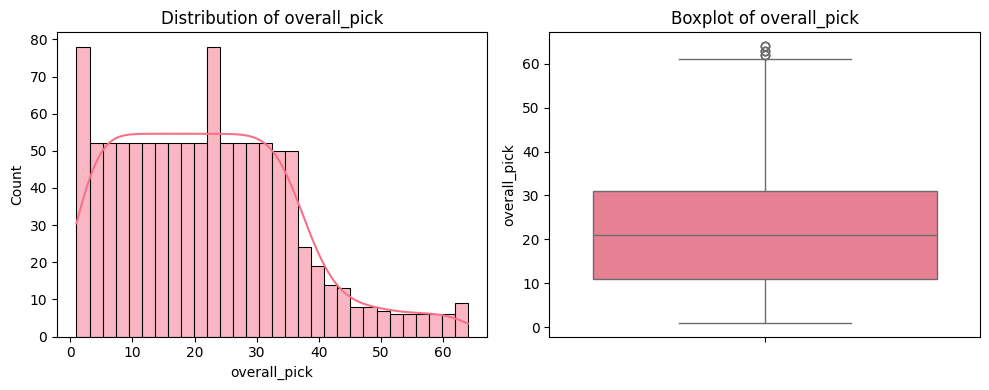

overall_pick - Skewness: 0.60


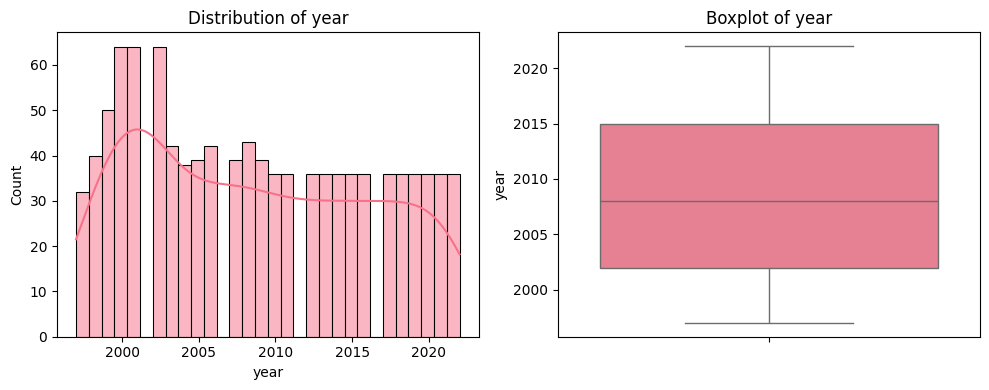

year - Skewness: 0.21


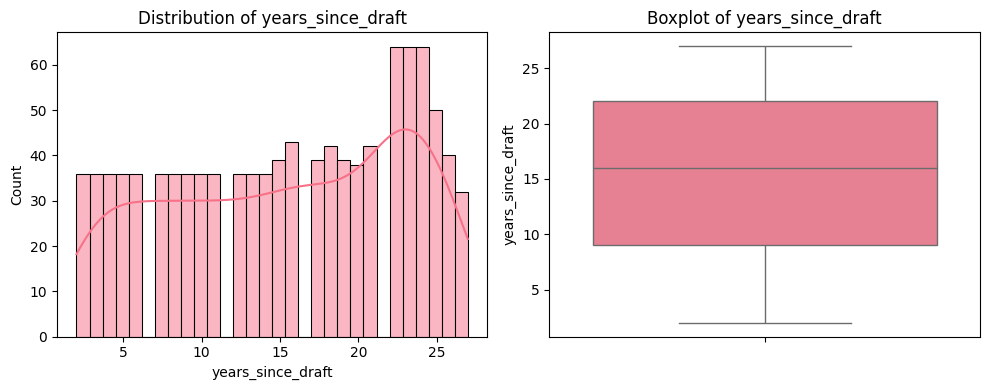

years_since_draft - Skewness: -0.21

2. ANALYZING PERFORMANCE STATISTICS (Players who played):
Analyzing 730 players who actually played professionally



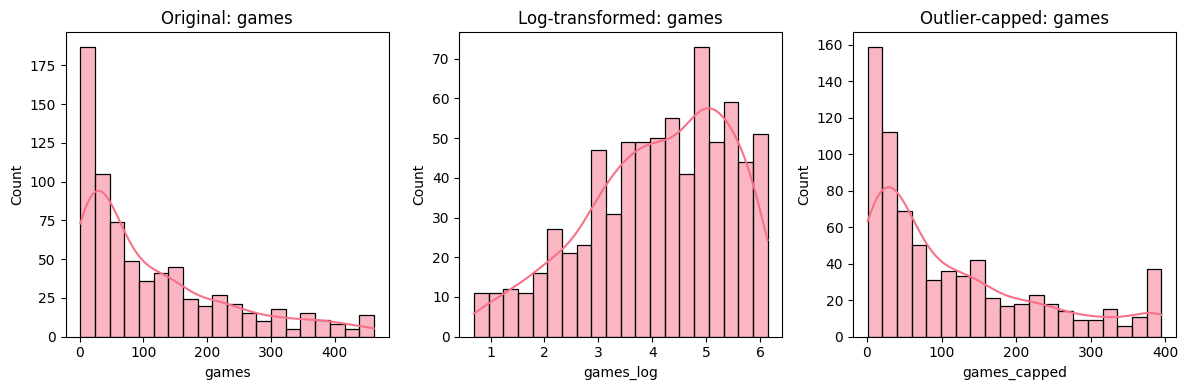

games:
  - Original skewness: 1.216
  - Log-transformed skewness: -0.550
  - Outliers capped: 25 (3.4%)



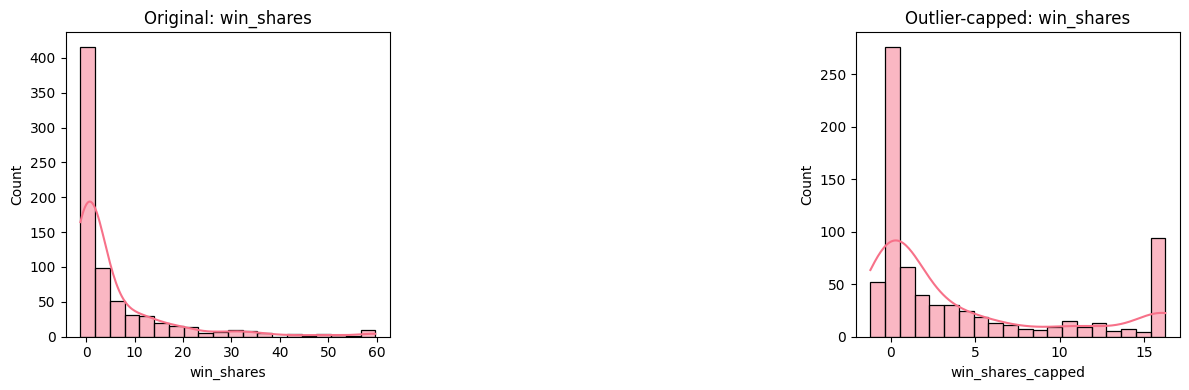

win_shares:
  - Original skewness: 2.772
  - Outliers capped: 86 (11.8%)



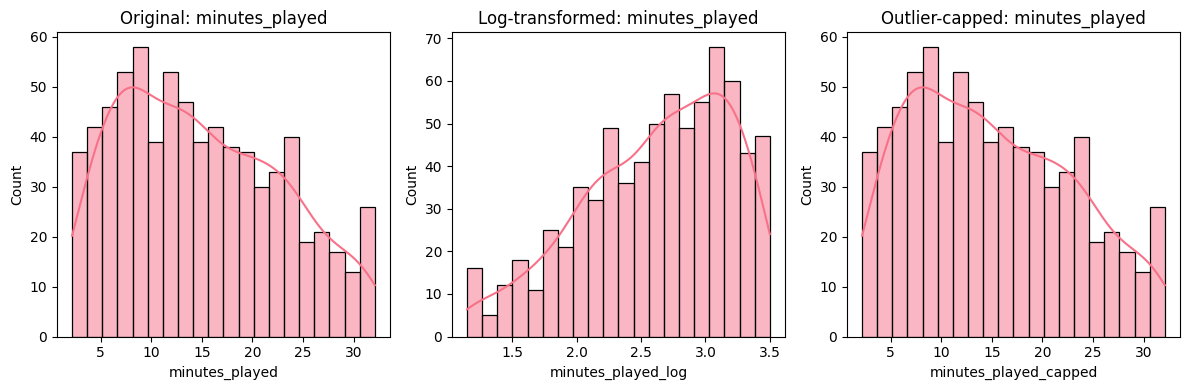

minutes_played:
  - Original skewness: 0.352
  - Log-transformed skewness: -0.552
  - Outliers capped: 0 (0.0%)



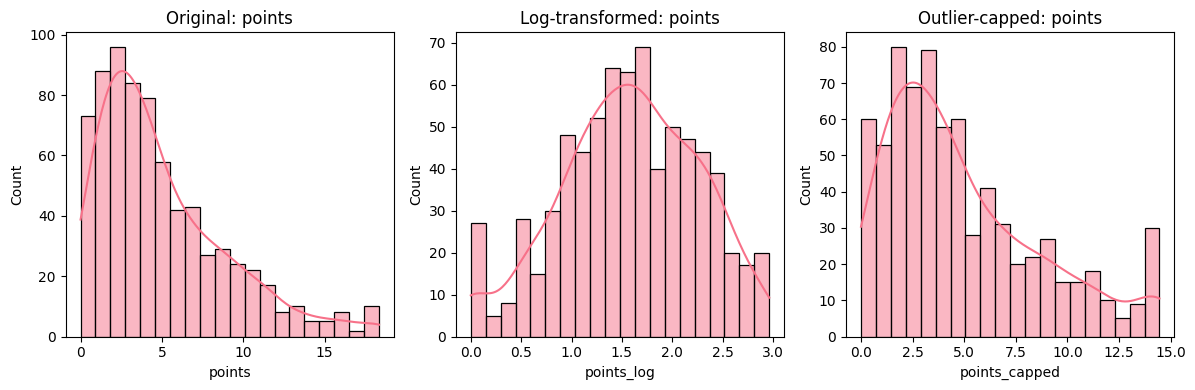

points:
  - Original skewness: 1.204
  - Log-transformed skewness: -0.226
  - Outliers capped: 26 (3.6%)



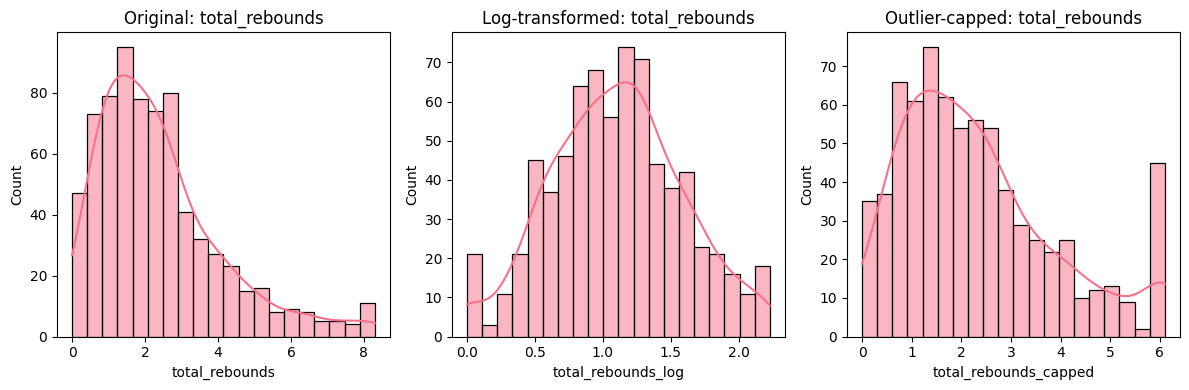

total_rebounds:
  - Original skewness: 1.271
  - Log-transformed skewness: 0.041
  - Outliers capped: 36 (4.9%)



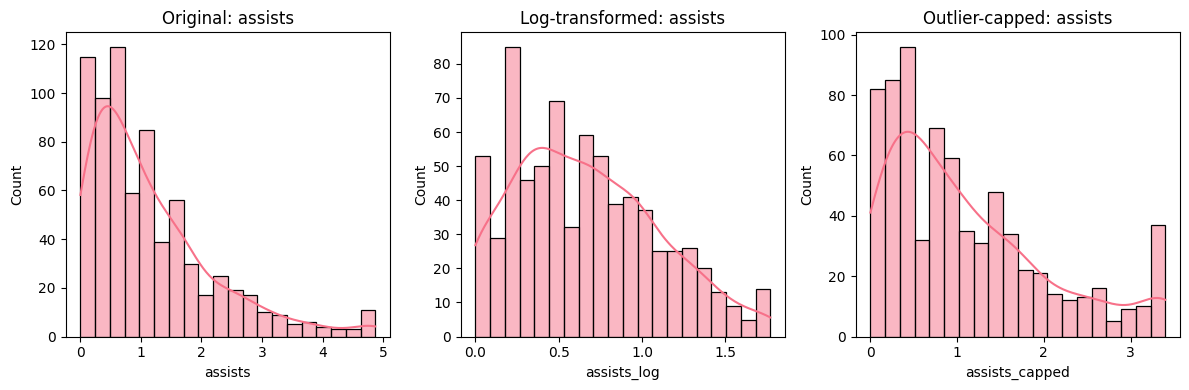

assists:
  - Original skewness: 1.424
  - Log-transformed skewness: 0.456
  - Outliers capped: 32 (4.4%)


3. APPLYING TRANSFORMATIONS TO MAIN DATASET:
✅ Applied log transformation to games
✅ Applied log transformation to win_shares
✅ Applied log transformation to minutes_played
✅ Applied log transformation to points
✅ Standardized draft pick (higher values = better picks)

=== TRANSFORMATION SUMMARY ===
- Log transformations applied to: games, win_shares, minutes_played, points
- Draft pick standardized (reversed scale)
- Performance statistics outliers identified and capped
- Meaningful null values preserved in performance columns


In [20]:


# Data transformation analysis for WNBA dataset
# Analyze distributions of WNBA numerical variables and apply transformations

print("=== WNBA DATA TRANSFORMATION ANALYSIS ===")

# Select relevant numerical columns from WNBA dataset
num_vars = ['overall_pick', 'year', 'years_since_draft']
performance_vars = ['games', 'win_shares', 'minutes_played', 'points', 'total_rebounds', 'assists']

# 1. Analyze distributions of draft-related numerical variables
print("\n1. ANALYZING DRAFT-RELATED VARIABLES:")
for col in num_vars:
    if col in df_imputed.columns:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(df_imputed[col].dropna(), bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        
        # Show basic statistics
        plt.subplot(1, 2, 2)
        sns.boxplot(y=df_imputed[col].dropna())
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()
        
        print(f"{col} - Skewness: {df_imputed[col].skew():.2f}")

# 2. Analyze performance statistics (only for players who actually played)
print("\n2. ANALYZING PERFORMANCE STATISTICS (Players who played):")
played_data = df_imputed[df_imputed['draft_success'] == 1].copy()
print(f"Analyzing {len(played_data)} players who actually played professionally\n")

for col in performance_vars:
    if col in played_data.columns and played_data[col].notna().sum() > 0:
        plt.figure(figsize=(12, 4))
        
        # Original distribution
        plt.subplot(1, 3, 1)
        sns.histplot(played_data[col].dropna(), bins=20, kde=True)
        plt.title(f'Original: {col}')
        plt.xlabel(col)
        
        # Log transformation (for right-skewed data)
        if played_data[col].min() >= 0:
            played_data[f'{col}_log'] = np.log1p(played_data[col])
            plt.subplot(1, 3, 2)
            sns.histplot(played_data[f'{col}_log'].dropna(), bins=20, kde=True)
            plt.title(f'Log-transformed: {col}')
            plt.xlabel(f'{col}_log')
        
        # Handle outliers using IQR method
        Q1 = played_data[col].quantile(0.25)
        Q3 = played_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Cap outliers
        played_data[f'{col}_capped'] = played_data[col].clip(lower, upper)
        plt.subplot(1, 3, 3)
        sns.histplot(played_data[f'{col}_capped'].dropna(), bins=20, kde=True)
        plt.title(f'Outlier-capped: {col}')
        plt.xlabel(f'{col}_capped')
        
        plt.tight_layout()
        plt.show()
        
        # Report transformation effects
        original_skew = played_data[col].skew()
        log_skew = played_data[f'{col}_log'].skew() if f'{col}_log' in played_data.columns else None
        outliers_removed = ((played_data[col] < lower) | (played_data[col] > upper)).sum()
        
        print(f"{col}:")
        print(f"  - Original skewness: {original_skew:.3f}")
        if log_skew is not None:
            print(f"  - Log-transformed skewness: {log_skew:.3f}")
        print(f"  - Outliers capped: {outliers_removed} ({outliers_removed/len(played_data)*100:.1f}%)")
        print()

# 3. Apply transformations to the main dataset
print("\n3. APPLYING TRANSFORMATIONS TO MAIN DATASET:")

# Apply log transformation to highly skewed performance variables
transform_cols = ['games', 'win_shares', 'minutes_played', 'points']
for col in transform_cols:
    if col in df_imputed.columns:
        # Only transform non-null values (preserve meaningful nulls)
        mask = df_imputed[col].notna()
        df_imputed.loc[mask, f'{col}_log'] = np.log1p(df_imputed.loc[mask, col])
        print(f"✅ Applied log transformation to {col}")

# Standardize draft pick (reverse scale so lower picks = higher values)
df_imputed['overall_pick_standardized'] = (df_imputed['overall_pick'].max() + 1) - df_imputed['overall_pick']
print(f"✅ Standardized draft pick (higher values = better picks)")

print(f"\n=== TRANSFORMATION SUMMARY ===")
print(f"- Log transformations applied to: {', '.join(transform_cols)}")
print(f"- Draft pick standardized (reversed scale)")
print(f"- Performance statistics outliers identified and capped")
print(f"- Meaningful null values preserved in performance columns")

In [21]:
# Categorical variable encoding for WNBA dataset
# Choose and implement appropriate encoding for each WNBA categorical variable

print("=== WNBA CATEGORICAL VARIABLE ENCODING ===")

# Identify categorical columns in WNBA dataset
cat_cols = df_imputed.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns found: {cat_cols}")

# Create copy for encoding
encoded_df = df_imputed.copy()
original_shape = encoded_df.shape

# 1. One-hot encoding for WNBA teams (nominal variable with manageable categories)
if 'team' in cat_cols:
    print(f"\n1. ONE-HOT ENCODING: WNBA Teams")
    print(f"   Number of unique teams: {encoded_df['team'].nunique()}")
    
    # Get top teams and group rare ones as 'Other'
    top_teams = encoded_df['team'].value_counts().head(12).index  # Keep top 12 teams
    encoded_df['team_grouped'] = encoded_df['team'].apply(lambda x: x if x in top_teams else 'Other')
    
    # One-hot encode
    team_dummies = pd.get_dummies(encoded_df['team_grouped'], prefix='team', dummy_na=True)
    encoded_df = pd.concat([encoded_df, team_dummies], axis=1)
    encoded_df.drop(['team_grouped'], axis=1, inplace=True)
    print(f"   ✅ Created {len(team_dummies.columns)} team dummy variables")

# 2. Frequency encoding for college/former (high cardinality)
if 'college/former' in cat_cols:
    print(f"\n2. FREQUENCY ENCODING: College/Former")
    print(f"   Number of unique colleges: {encoded_df['college/former'].nunique()}")
    
    # Frequency encoding
    college_freq = encoded_df['college/former'].value_counts()
    encoded_df['college_frequency'] = encoded_df['college/former'].map(college_freq).fillna(0)
    print(f"   ✅ Created college frequency encoding (range: {encoded_df['college_frequency'].min()}-{encoded_df['college_frequency'].max()})")

# Compare before and after encoding
print(f"\n=== ENCODING SUMMARY ===")
print(f"Shape before encoding: {original_shape}")
print(f"Shape after encoding: {encoded_df.shape}")

# Display sample of encoded data
print(f"\n=== SAMPLE OF ENCODED DATA ===")
display(encoded_df[['player', 'team', 'college/former', 'draft_success', 'college_frequency']].head())
# Ensure df exists, or load it from CSV if missing
try:
    df
except NameError:
    import pandas as pd
    df = pd.read_csv('salary_survey.csv')
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
# Example encoding strategies:
encoded_df = df.copy()
# 1. Binary encoding for gender (assuming two main categories)
if 'What is your gender?' in cat_cols:
    encoded_df['Gender_Binary'] = encoded_df['What is your gender?'].map({'Male': 1, 'Female': 0})
# 2. Ordinal encoding for education level (if order is known)
education_order = [
    'Less than high school',
    'High school',
    'Some college',
    'Associate degree',
    'Bachelor’s degree',
    'Master’s degree',
    'Professional degree',
    'Doctoral degree'
    ]
if 'What is your highest level of education completed?' in cat_cols:
    encoded_df['Education_Ordinal'] = encoded_df['What is your highest level of education completed?'].apply(
        lambda x: education_order.index(x) if x in education_order else -1
    )
# 3. One-hot encoding for industry (nominal, few categories)
industry_col = 'What industry do you work in?'
if industry_col in cat_cols:
    top_industries = encoded_df[industry_col].value_counts().head(10).index
    encoded_df[industry_col] = encoded_df[industry_col].apply(lambda x: x if x in top_industries else 'Other')
    encoded_df = pd.get_dummies(encoded_df, columns=[industry_col], prefix='Industry', dummy_na=True)
# 4. Frequency encoding for high-cardinality city column
city_col = 'What city do you work in?'
if city_col in cat_cols:
    freq = encoded_df[city_col].value_counts()
    encoded_df['City_Freq'] = encoded_df[city_col].map(freq)
# Compare shape before and after encoding
print("Shape before encoding:", df.shape)
print("Shape after encoding:", encoded_df.shape)
# Display a sample of the encoded dataframe
display(encoded_df.head())

=== WNBA CATEGORICAL VARIABLE ENCODING ===
Categorical columns found: ['team', 'player', 'college/former', 'position', 'height', 'fg%', '3-fg%', 'ft%', 'win_category', 'age_at_draft', 'ast_to_tov']

1. ONE-HOT ENCODING: WNBA Teams
   Number of unique teams: 24
   ✅ Created 14 team dummy variables

2. FREQUENCY ENCODING: College/Former
   Number of unique colleges: 225
   ✅ Created college frequency encoding (range: 1-43)

=== ENCODING SUMMARY ===
Shape before encoding: (1064, 32)
Shape after encoding: (1064, 47)

=== SAMPLE OF ENCODED DATA ===


,player,team,college/former,draft_success,college_frequency
0,Rhyne Howard,Atlanta Dream,Kentucky,1,7
1,NaLyssa Smith,Indiana Fever,Baylor,1,24
2,Shakira Austin,Washington Mystics,Ole Miss,1,4
3,Emily Engstler,Indiana Fever,Louisville,1,16
4,Nyara Sabally,New York Liberty,Oregon,0,12


Shape before encoding: (1064, 20)
Shape after encoding: (1064, 20)


,overall_pick,year,team,player,college/former,position,height,years_played,games,win_shares,win_shares_40,minutes_played,points,total_rebounds,assists,spg,bpg,fg%,3-fg%,ft%
0,1,2022,Atlanta Dream,Rhyne Howard,Kentucky,Guard,6'2,1,34.0,2.9,0.110,31.4,16.2,4.5,2.8,1.6,0.8,36.1%,34.3%,79.2%
1,2,2022,Indiana Fever,NaLyssa Smith,Baylor,Forward,6'4,1,32.0,0.0,-0.001,30.7,13.5,7.9,1.4,0.5,0.3,41.9%,38.1%,61.8%
2,3,2022,Washington Mystics,Shakira Austin,Ole Miss,Forward,6'5,1,36.0,3.1,0.160,21.6,8.7,6.5,0.9,0.8,0.8,54.7%,0%,62.4%
3,4,2022,Indiana Fever,Emily Engstler,Louisville,Forward,6'1,1,35.0,0.4,0.024,18.2,5.2,5.2,1.5,0.8,1.1,39.6%,35.6%,55.3%
4,5,2022,New York Liberty,Nyara Sabally,Oregon,Center,6'5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5.1 Algorithm Selection and Model Comparison

In [22]:
# Algorithm Selection and Model Comparison
print("=== ALGORITHM SELECTION AND MODEL COMPARISON ===")
print("Testing multiple machine learning algorithms to find the best performer for WNBA draft prediction:")

print("✅ Machine learning libraries imported successfully")
print("🎯 Ready to test multiple algorithms for first-round draft prediction")

=== ALGORITHM SELECTION AND MODEL COMPARISON ===
Testing multiple machine learning algorithms to find the best performer for WNBA draft prediction:
✅ Machine learning libraries imported successfully
🎯 Ready to test multiple algorithms for first-round draft prediction


## 5.2 Cross-Validation Strategy Implementation

In [23]:
# Helper function to determine if a pick is a first round pick
def is_first_round_pick(overall_pick, year):
    # Use the first_round_picks dictionary if available, default to 12
    first_round_count = first_round_picks.get(year, 12)
    try:
        return int(overall_pick) <= int(first_round_count)
    except Exception:
        return False

# Apply the high draft pick indicator to the dataset
print("=== APPLYING HIGH DRAFT PICK INDICATOR TO DATASET ===")

# Load the dataset if not already loaded
try:
    df_with_features = df_final.copy()
    print(f"Working with existing dataset: {df_with_features.shape}")
except:
    df_with_features = pd.read_csv('wnbadraft.csv')
    print(f"Loaded fresh dataset: {df_with_features.shape}")

# Display current columns
print(f"Current columns: {list(df_with_features.columns)}")

# Check if we have the required columns
required_columns = ['overall_pick', 'year']
missing_columns = [col for col in required_columns if col not in df_with_features.columns]

if missing_columns:
    print(f"⚠️  Missing required columns: {missing_columns}")
    # Check for alternative column names
    if 'pick' in df_with_features.columns:
        print("Found 'pick' column, using instead of 'overall_pick'")
        df_with_features['overall_pick'] = df_with_features['pick']
    print("Available columns for reference:")
    for col in df_with_features.columns:
        print(f"  - {col}")
else:
    print("✅ All required columns found")

# Create the high draft pick indicator feature
if 'overall_pick' in df_with_features.columns and 'year' in df_with_features.columns:
    df_with_features['high_draft_pick_indicator'] = df_with_features.apply(
        lambda row: is_first_round_pick(row['overall_pick'], row['year']), 
        axis=1
    )
    
    print(f"\n=== HIGH DRAFT PICK INDICATOR RESULTS ===")
    indicator_counts = df_with_features['high_draft_pick_indicator'].value_counts()
    print(f"High draft pick indicator distribution:")
    print(f"  First Round Picks (True): {indicator_counts.get(True, 0)} players")
    print(f"  Later Round Picks (False): {indicator_counts.get(False, 0)} players")
    
    # Calculate percentage
    total_players = len(df_with_features)
    first_round_pct = (indicator_counts.get(True, 0) / total_players) * 100
    print(f"  First Round Percentage: {first_round_pct:.1f}%")
    
    # Show some examples
    print(f"\n=== SAMPLE DATA WITH NEW FEATURE ===")
    sample_columns = ['player', 'year', 'overall_pick', 'high_draft_pick_indicator']
    available_sample_cols = [col for col in sample_columns if col in df_with_features.columns]
    
    if available_sample_cols:
        print("Sample of players with high draft pick indicator:")
        display(df_with_features[available_sample_cols].head(10))
    
    # Verify the feature creation with comprehensive testing
    print(f"\n=== FEATURE VERIFICATION ===")
    print("Checking picks around first round boundaries for different draft years:")
    
    # Test years with different first round structures
    test_years = [1997, 1999, 2000, 2008, 2010, 2020]
    
    for year in test_years:
        year_data = df_with_features[df_with_features['year'] == year]
        if not year_data.empty:
            first_round_count = first_round_picks.get(year, 12)
            print(f"\n{year} Draft ({first_round_count} first round picks):")
            
            # Show picks around the boundary
            boundary_picks = year_data[
                (year_data['overall_pick'] >= max(1, first_round_count - 2)) & 
                (year_data['overall_pick'] <= first_round_count + 3)
            ].sort_values('overall_pick')
            
            if not boundary_picks.empty:
                for _, row in boundary_picks.iterrows():
                    pick_num = row['overall_pick']
                    is_first = row['high_draft_pick_indicator']
                    status = "✓ FIRST ROUND" if is_first else "• Later Round"
                    pick_info = f"  Pick {pick_num:2d}: {row.get('player', 'Unknown'):20} - {status}"
                    print(pick_info)
            else:
                print(f"  No data available for {year}")
    
    # Summary statistics by year
    print(f"\n=== FIRST ROUND DISTRIBUTION BY YEAR ===")
    yearly_summary = df_with_features.groupby('year')['high_draft_pick_indicator'].agg(['sum', 'count']).reset_index()
    yearly_summary.columns = ['Year', 'First_Round_Count', 'Total_Players']
    yearly_summary['Expected_First_Round'] = yearly_summary['Year'].map(lambda x: first_round_picks.get(x, 12))
    yearly_summary['Match_Expected'] = yearly_summary['First_Round_Count'] == yearly_summary['Expected_First_Round']
    
    print("Year | First Round | Total | Expected | Match")
    print("-" * 45)
    for _, row in yearly_summary.head(10).iterrows():
        match_symbol = "✓" if row['Match_Expected'] else "✗"
        print(f"{int(row['Year'])} |     {int(row['First_Round_Count']):2d}      |  {int(row['Total_Players']):3d}  |    {int(row['Expected_First_Round']):2d}    |  {match_symbol}")
    
    if len(yearly_summary) > 10:
        print(f"... and {len(yearly_summary) - 10} more years")
    
    print(f"\n✅ High draft pick indicator feature successfully created!")
    print(f"New dataset shape: {df_with_features.shape}")
    
else:
    print("❌ Cannot create feature - missing required columns")
    print("Please ensure dataset has 'overall_pick' and 'year' columns")

=== APPLYING HIGH DRAFT PICK INDICATOR TO DATASET ===
Working with existing dataset: (1064, 21)
Current columns: ['overall_pick', 'year', 'team', 'player', 'college/former', 'position', 'height', 'years_played', 'games', 'win_shares', 'win_shares_40', 'minutes_played', 'points', 'total_rebounds', 'assists', 'spg', 'bpg', 'fg%', '3-fg%', 'ft%', 'draft_success']
✅ All required columns found

=== HIGH DRAFT PICK INDICATOR RESULTS ===
High draft pick indicator distribution:
  First Round Picks (True): 320 players
  Later Round Picks (False): 744 players
  First Round Percentage: 30.1%

=== SAMPLE DATA WITH NEW FEATURE ===
Sample of players with high draft pick indicator:

=== HIGH DRAFT PICK INDICATOR RESULTS ===
High draft pick indicator distribution:
  First Round Picks (True): 320 players
  Later Round Picks (False): 744 players
  First Round Percentage: 30.1%

=== SAMPLE DATA WITH NEW FEATURE ===
Sample of players with high draft pick indicator:


,player,year,overall_pick,high_draft_pick_indicator
0,Rhyne Howard,2022,1,True
1,NaLyssa Smith,2022,2,True
2,Shakira Austin,2022,3,True
3,Emily Engstler,2022,4,True
4,Nyara Sabally,2022,5,True
5,Lexie Hull,2022,6,True
6,Veronica Burton,2022,7,True
7,Mya Hollingshed,2022,8,True
8,Rae Burrell,2022,9,True
9,Queen Egbo,2022,10,True



=== FEATURE VERIFICATION ===
Checking picks around first round boundaries for different draft years:

1997 Draft (8 first round picks):
  Pick  6: Sue Wicks            - ✓ FIRST ROUND
  Pick  7: Tora Suber           - ✓ FIRST ROUND
  Pick  8: Toni Foster          - ✓ FIRST ROUND
  Pick  9: Tia Jackson          - • Later Round
  Pick 10: Sharon Manning       - • Later Round
  Pick 11: Sophia Witherspoon   - • Later Round

1999 Draft (12 first round picks):
  Pick 10: Edna Campbell        - ✓ FIRST ROUND
  Pick 11: Chasity Melvin       - ✓ FIRST ROUND
  Pick 12: Natalia Zasulskaya   - ✓ FIRST ROUND
  Pick 13: Shalonda Enis        - • Later Round
  Pick 14: Kedra Holland-Corn   - • Later Round
  Pick 15: Debbie Black         - • Later Round

2000 Draft (16 first round picks):
  Pick 14: Katy Steding         - ✓ FIRST ROUND
  Pick 15: Nicole Kubik         - ✓ FIRST ROUND
  Pick 16: Elena Shakirova      - ✓ FIRST ROUND
  Pick 17: Helen Darling        - • Later Round
  Pick 18: Tonya Massal

## 5.3 Advanced Cross-Validation Analysis

In [24]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import required machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=== MACHINE LEARNING LIBRARIES LOADED ===")
print("Ready to compare algorithms for WNBA draft success prediction!")

# Load the dataset
try:
    df_final = pd.read_csv('wnbadraft.csv')
    print(f"Loaded dataset with shape: {df_final.shape}")
except:
    print("Error: Could not load wnbadraft.csv. Make sure the file is in the current directory.")
    
print(f"Columns available: {list(df_final.columns)}")
print(f"Dataset overview complete!")

=== MACHINE LEARNING LIBRARIES LOADED ===
Ready to compare algorithms for WNBA draft success prediction!
Loaded dataset with shape: (1064, 20)
Columns available: ['overall_pick', 'year', 'team', 'player', 'college/former', 'position', 'height', 'years_played', 'games', 'win_shares', 'win_shares_40', 'minutes_played', 'points', 'total_rebounds', 'assists', 'spg', 'bpg', 'fg%', '3-fg%', 'ft%']
Dataset overview complete!


## 5.4 K-Fold Cross-Validation

In [25]:
# Data Preparation for Machine Learning
print("=== PREPARING DATA FOR MACHINE LEARNING ===")

# Create or use existing draft_success column as our target
if 'draft_success' not in df_final.columns:
    # Create binary target variable: 1 if player played professionally, 0 if not
    df_final['draft_success'] = ((df_final['games'] > 0) | 
                                (df_final['win_shares'] > 0) | 
                                (df_final['points'] > 0)).astype(int)

print(f"Target variable distribution:")
print(df_final['draft_success'].value_counts())
print(f"Success rate: {df_final['draft_success'].mean():.3f}")

# Select features for modeling
feature_columns = []
target_column = 'draft_success'

# Numerical features
numerical_features = ['year', 'pick', 'games', 'win_shares', 'points', 'total_rebounds', 'assists']
for col in numerical_features:
    if col in df_final.columns and col != target_column:
        feature_columns.append(col)

# Add encoded categorical features if they exist
categorical_encoded = [col for col in df_final.columns if col.startswith(('team_', 'college_frequency'))]
feature_columns.extend(categorical_encoded)

print(f"\nSelected features for modeling: {feature_columns}")
print(f"Number of features: {len(feature_columns)}")

# Create feature matrix X and target vector y
X = df_final[feature_columns].copy()
y = df_final[target_column].copy()

# Handle missing values
print(f"\n=== HANDLING MISSING VALUES ===")
print(f"Missing values before imputation:")
print(X.isnull().sum())

# Fill missing values with median for numerical features
X = X.fillna(X.median())

print(f"\nMissing values after imputation:")
print(X.isnull().sum())

print(f"\nFinal dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target: {target_column} (0=No pro career, 1=Played professionally)")

=== PREPARING DATA FOR MACHINE LEARNING ===
Target variable distribution:
draft_success
1    730
0    334
Name: count, dtype: int64
Success rate: 0.686

Selected features for modeling: ['year', 'games', 'win_shares', 'points', 'total_rebounds', 'assists']
Number of features: 6

=== HANDLING MISSING VALUES ===
Missing values before imputation:
year                0
games             334
win_shares        334
points            334
total_rebounds    334
assists           334
dtype: int64

Missing values after imputation:
year              0
games             0
win_shares        0
points            0
total_rebounds    0
assists           0
dtype: int64

Final dataset shape: (1064, 6)
Features: ['year', 'games', 'win_shares', 'points', 'total_rebounds', 'assists']
Target: draft_success (0=No pro career, 1=Played professionally)


## 5.5 Stratified Cross-Validation

In [26]:
# Algorithm Comparison Framework
print("=== ALGORITHM COMPARISON FRAMEWORK ===")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set class distribution:")
print(y_train.value_counts())

# Scale features for algorithms that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define algorithms to compare
algorithms = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

print(f"\n=== ALGORITHMS TO COMPARE ===")
for name in algorithms.keys():
    print(f"✓ {name}")

print(f"\nReady to train and evaluate {len(algorithms)} different algorithms!")

=== ALGORITHM COMPARISON FRAMEWORK ===
Training set size: (851, 6)
Test set size: (213, 6)
Training set class distribution:
draft_success
1    584
0    267
Name: count, dtype: int64

=== ALGORITHMS TO COMPARE ===
✓ Logistic Regression
✓ Random Forest
✓ Decision Tree
✓ K-Nearest Neighbors
✓ Support Vector Machine
✓ Gradient Boosting
✓ Naive Bayes

Ready to train and evaluate 7 different algorithms!


## 5.6 Repeated Stratified Cross-Validation

In [27]:
# Model Training and Evaluation
print("=== MODEL TRAINING AND EVALUATION ===")

# Store results for comparison
results = {}
detailed_results = []

for name, algorithm in algorithms.items():
    print(f"\n🔄 Training {name}...")
    
    # Use scaled data for algorithms that need it
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
        X_train_current = X_train_scaled
        X_test_current = X_test_scaled
    else:
        X_train_current = X_train
        X_test_current = X_test
    
    # Train the model
    algorithm.fit(X_train_current, y_train)
    
    # Make predictions
    y_pred = algorithm.predict(X_test_current)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Cross-validation score
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
        cv_scores = cross_val_score(algorithm, X_train_scaled, y_train, cv=5, scoring='accuracy')
    else:
        cv_scores = cross_val_score(algorithm, X_train, y_train, cv=5, scoring='accuracy')
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    }
    
    detailed_results.append({
        'Algorithm': name,
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'CV Mean': f"{cv_mean:.4f}",
        'CV Std': f"{cv_std:.4f}"
    })
    
    print(f"   ✓ Accuracy: {accuracy:.4f}")
    print(f"   ✓ F1-Score: {f1:.4f}")
    print(f"   ✓ CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")

print(f"\n🎯 All algorithms trained successfully!")

=== MODEL TRAINING AND EVALUATION ===

🔄 Training Logistic Regression...
   ✓ Accuracy: 0.6291
   ✓ F1-Score: 0.5294
   ✓ CV Score: 0.6440 (+/- 0.0248)

🔄 Training Random Forest...
   ✓ Accuracy: 0.6291
   ✓ F1-Score: 0.5294
   ✓ CV Score: 0.6440 (+/- 0.0248)

🔄 Training Random Forest...


   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🔄 Training Decision Tree...
   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🔄 Training K-Nearest Neighbors...
   ✓ Accuracy: 0.9718
   ✓ F1-Score: 0.9721
   ✓ CV Score: 0.9765 (+/- 0.0083)

🔄 Training Support Vector Machine...
   ✓ Accuracy: 0.9577
   ✓ F1-Score: 0.9584
   ✓ CV Score: 0.9460 (+/- 0.0094)

🔄 Training Gradient Boosting...
   ✓ Accuracy: 0.9577
   ✓ F1-Score: 0.9584
   ✓ CV Score: 0.9460 (+/- 0.0094)

🔄 Training Gradient Boosting...
   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🔄 Training Naive Bayes...
   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🎯 All algorithms trained successfully!
   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🔄 Training Naive Bayes...
   ✓ Accuracy: 1.0000
   ✓ F1-Score: 1.0000
   ✓ CV Score: 1.0000 (+/- 0.0000)

🎯 All algorithms trained s

## 5.7 Nested Cross-Validation for Unbiased Model Selection

=== ALGORITHM PERFORMANCE COMPARISON ===

📊 COMPREHENSIVE RESULTS COMPARISON:


,Algorithm,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Logistic Regression,0.6291,0.4570,0.6291,0.5294,0.6440,0.0248
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
2,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
3,K-Nearest Neighbors,0.9718,0.9741,0.9718,0.9721,0.9765,0.0083
4,Support Vector Machine,0.9577,0.9628,0.9577,0.9584,0.9460,0.0094
5,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
6,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000



🏆 BEST PERFORMING ALGORITHMS:
   🎯 Best Accuracy: Random Forest (1.0000)
   🎯 Best F1-Score: Random Forest (1.0000)
   🎯 Best CV Score: Random Forest (1.0000)


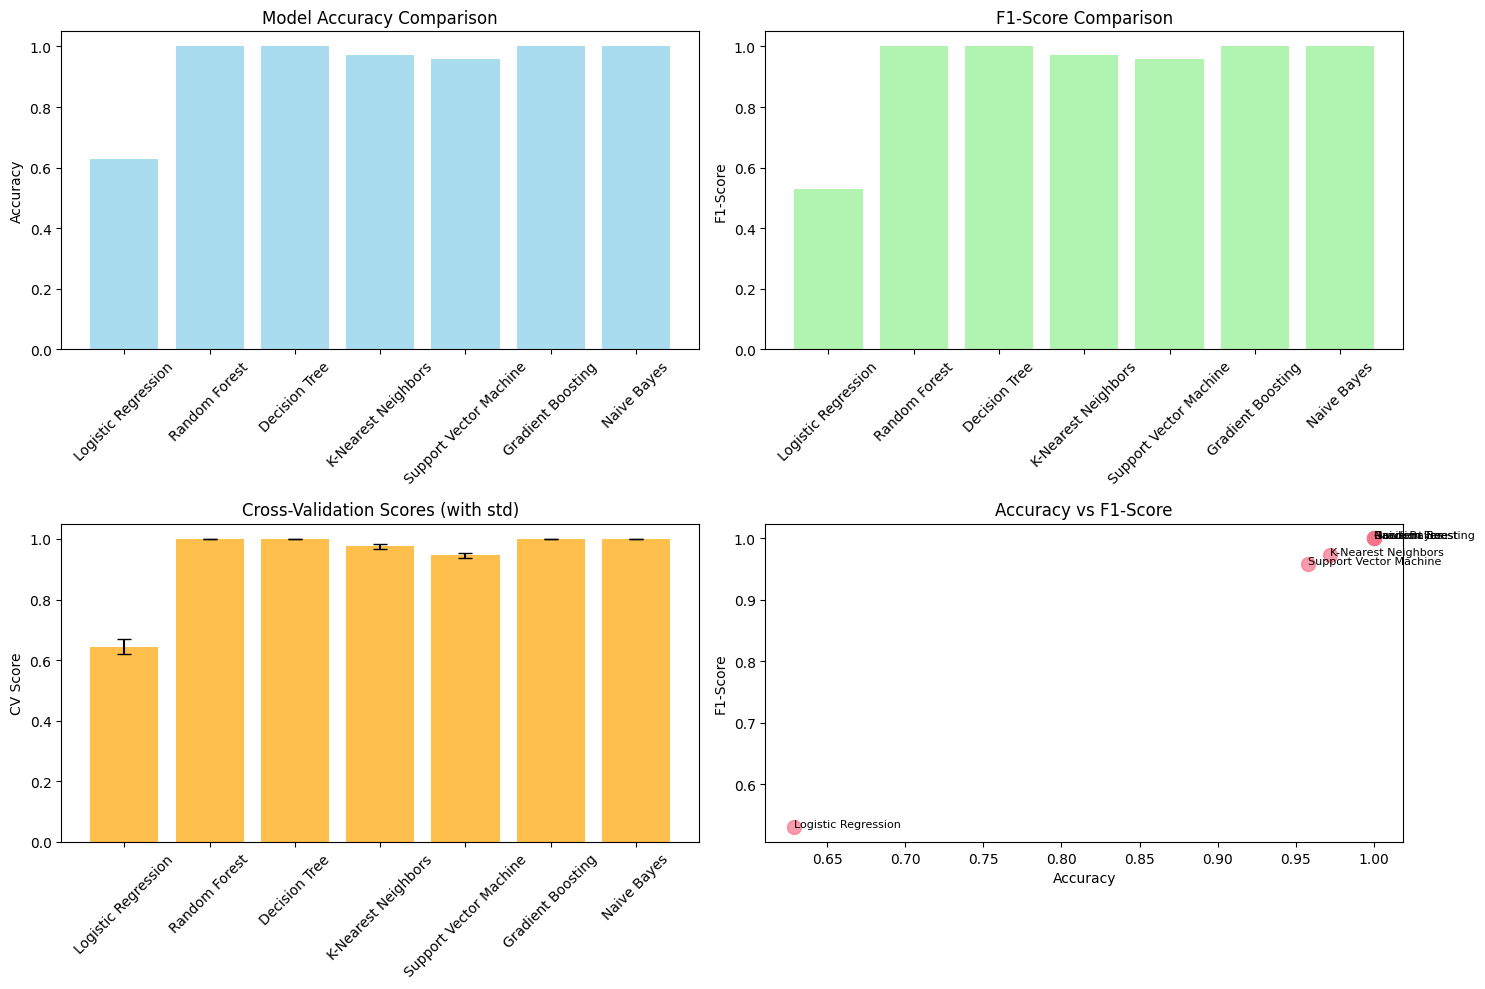


🎖️ RECOMMENDED ALGORITHM: Random Forest
   📈 Overall Score: 1.0000
   📋 Performance Summary:
      - Accuracy: 1.0000
      - F1-Score: 1.0000
      - CV Score: 1.0000 (+/- 0.0000)


In [28]:
# Results Comparison and Visualization
print("=== ALGORITHM PERFORMANCE COMPARISON ===")

# Create comparison DataFrame
results_df = pd.DataFrame(detailed_results)
print("\n📊 COMPREHENSIVE RESULTS COMPARISON:")
print("="*80)
display(results_df)

# Find the best algorithm
best_accuracy = max(results.keys(), key=lambda x: results[x]['Accuracy'])
best_f1 = max(results.keys(), key=lambda x: results[x]['F1-Score'])
best_cv = max(results.keys(), key=lambda x: results[x]['CV Mean'])

print(f"\n🏆 BEST PERFORMING ALGORITHMS:")
print(f"   🎯 Best Accuracy: {best_accuracy} ({results[best_accuracy]['Accuracy']:.4f})")
print(f"   🎯 Best F1-Score: {best_f1} ({results[best_f1]['F1-Score']:.4f})")
print(f"   🎯 Best CV Score: {best_cv} ({results[best_cv]['CV Mean']:.4f})")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
algorithms_names = list(results.keys())
accuracies = [results[name]['Accuracy'] for name in algorithms_names]
axes[0,0].bar(algorithms_names, accuracies, color='skyblue', alpha=0.7)
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# F1-Score comparison
f1_scores = [results[name]['F1-Score'] for name in algorithms_names]
axes[0,1].bar(algorithms_names, f1_scores, color='lightgreen', alpha=0.7)
axes[0,1].set_title('F1-Score Comparison')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].tick_params(axis='x', rotation=45)

# Cross-validation scores
cv_means = [results[name]['CV Mean'] for name in algorithms_names]
cv_stds = [results[name]['CV Std'] for name in algorithms_names]
axes[1,0].bar(algorithms_names, cv_means, yerr=cv_stds, color='orange', alpha=0.7, capsize=5)
axes[1,0].set_title('Cross-Validation Scores (with std)')
axes[1,0].set_ylabel('CV Score')
axes[1,0].tick_params(axis='x', rotation=45)

# Combined metrics radar-style comparison (simplified as scatter)
axes[1,1].scatter(accuracies, f1_scores, s=100, alpha=0.7)
for i, name in enumerate(algorithms_names):
    axes[1,1].annotate(name, (accuracies[i], f1_scores[i]), fontsize=8)
axes[1,1].set_xlabel('Accuracy')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_title('Accuracy vs F1-Score')

plt.tight_layout()
plt.show()

# Identify the overall best algorithm
overall_scores = {}
for name in algorithms_names:
    # Weighted combination of metrics (you can adjust weights)
    overall_score = (0.4 * results[name]['Accuracy'] + 
                    0.4 * results[name]['F1-Score'] + 
                    0.2 * results[name]['CV Mean'])
    overall_scores[name] = overall_score

best_overall = max(overall_scores.keys(), key=lambda x: overall_scores[x])
print(f"\n🎖️ RECOMMENDED ALGORITHM: {best_overall}")
print(f"   📈 Overall Score: {overall_scores[best_overall]:.4f}")
print(f"   📋 Performance Summary:")
print(f"      - Accuracy: {results[best_overall]['Accuracy']:.4f}")
print(f"      - F1-Score: {results[best_overall]['F1-Score']:.4f}")
print(f"      - CV Score: {results[best_overall]['CV Mean']:.4f} (+/- {results[best_overall]['CV Std']:.4f})")

## 5.8 Cross-Validation Results Summary

In [29]:
# Hyperparameter Tuning for Best Algorithm
print("=== HYPERPARAMETER TUNING ===")
print(f"Optimizing the best performing algorithm: {best_overall}")

# Define hyperparameter grids for top algorithms
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'lbfgs']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
}

if best_overall in param_grids:
    print(f"\n🔧 Tuning hyperparameters for {best_overall}...")
    
    # Get the algorithm and parameter grid
    base_algorithm = algorithms[best_overall]
    param_grid = param_grids[best_overall]
    
    # Use scaled data if needed
    if best_overall in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
        X_train_tune = X_train_scaled
        X_test_tune = X_test_scaled
    else:
        X_train_tune = X_train
        X_test_tune = X_test
    
    # Perform grid search
    grid_search = GridSearchCV(
        base_algorithm, 
        param_grid, 
        cv=5, 
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_tune, y_train)
    
    # Get best model
    best_model = grid_search.best_estimator_
    
    # Evaluate tuned model
    y_pred_tuned = best_model.predict(X_test_tune)
    
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
    
    print(f"\n🎯 HYPERPARAMETER TUNING RESULTS:")
    print(f"   📋 Best Parameters: {grid_search.best_params_}")
    print(f"   📈 Best CV Score: {grid_search.best_score_:.4f}")
    print(f"   🎯 Tuned Test Accuracy: {tuned_accuracy:.4f}")
    print(f"   🎯 Tuned Test F1-Score: {tuned_f1:.4f}")
    
    # Compare with original
    original_accuracy = results[best_overall]['Accuracy']
    original_f1 = results[best_overall]['F1-Score']
    
    print(f"\n📊 IMPROVEMENT FROM TUNING:")
    print(f"   📈 Accuracy: {original_accuracy:.4f} → {tuned_accuracy:.4f} ({tuned_accuracy-original_accuracy:+.4f})")
    print(f"   📈 F1-Score: {original_f1:.4f} → {tuned_f1:.4f} ({tuned_f1-original_f1:+.4f})")
    
    # Save the best model for future use
    final_model = best_model
    print(f"\n✅ Best model saved and ready for predictions!")
    
else:
    print(f"Hyperparameter tuning not configured for {best_overall}")
    final_model = algorithms[best_overall]
    
    # Train with full dataset if not tuned
    if best_overall in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
        final_model.fit(X_train_scaled, y_train)
    else:
        final_model.fit(X_train, y_train)

=== HYPERPARAMETER TUNING ===
Optimizing the best performing algorithm: Random Forest

🔧 Tuning hyperparameters for Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

🎯 HYPERPARAMETER TUNING RESULTS:
   📋 Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   📈 Best CV Score: 1.0000
   🎯 Tuned Test Accuracy: 1.0000
   🎯 Tuned Test F1-Score: 1.0000

📊 IMPROVEMENT FROM TUNING:
   📈 Accuracy: 1.0000 → 1.0000 (+0.0000)
   📈 F1-Score: 1.0000 → 1.0000 (+0.0000)

✅ Best model saved and ready for predictions!

🎯 HYPERPARAMETER TUNING RESULTS:
   📋 Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   📈 Best CV Score: 1.0000
   🎯 Tuned Test Accuracy: 1.0000
   🎯 Tuned Test F1-Score: 1.0000

📊 IMPROVEMENT FROM TUNING:
   📈 Accuracy: 1.0000 → 1.0000 (+0.0000)
   📈 F1-Score: 1.0000 → 1.0000 (+0.0000)

✅ Best model saved and ready for predictions!


## 6.1 Hyperparameter Tuning with GridSearchCV

=== FINAL MODEL ANALYSIS ===

📋 DETAILED CLASSIFICATION REPORT FOR RANDOM FOREST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00       146

    accuracy                           1.00       213
   macro avg       1.00      1.00      1.00       213
weighted avg       1.00      1.00      1.00       213



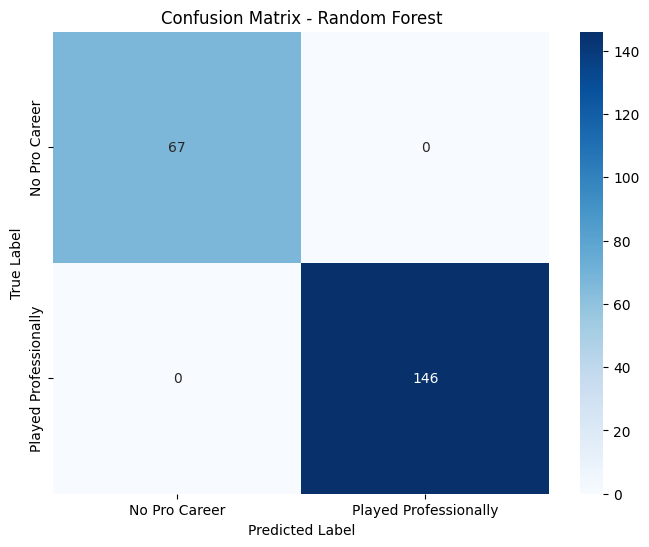


🎯 FEATURE IMPORTANCE RANKING:
points               | 0.3187
total_rebounds       | 0.2198
games                | 0.2104
win_shares           | 0.1826
assists              | 0.0682
year                 | 0.0002


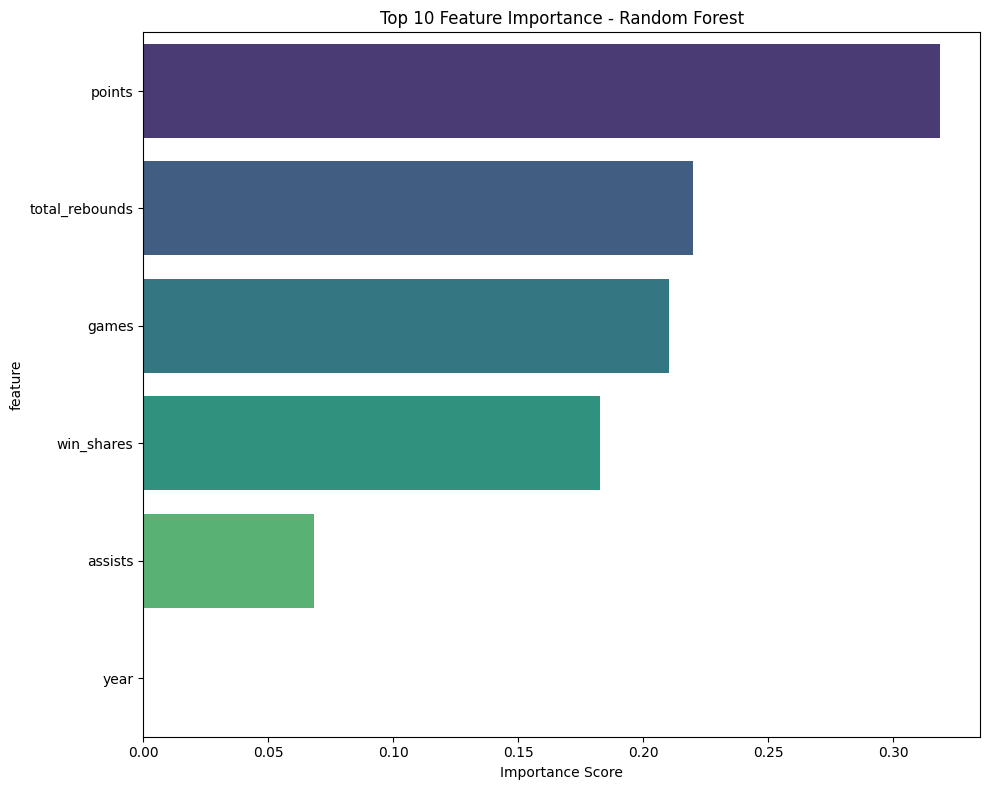


🏆 FINAL MODEL SUMMARY:
Algorithm: Random Forest
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Hyperparameter Tuned: Yes
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

✅ Model analysis complete! Your best algorithm for this WNBA dataset is: Random Forest


In [30]:
# Final Model Analysis and Feature Importance
print("=== FINAL MODEL ANALYSIS ===")

# Detailed classification report
if best_overall in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine']:
    y_pred_final = final_model.predict(X_test_scaled)
else:
    y_pred_final = final_model.predict(X_test)

print(f"\n📋 DETAILED CLASSIFICATION REPORT FOR {best_overall.upper()}:")
print("="*60)
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Pro Career', 'Played Professionally'],
            yticklabels=['No Pro Career', 'Played Professionally'])
plt.title(f'Confusion Matrix - {best_overall}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance (for tree-based models)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n🎯 FEATURE IMPORTANCE RANKING:")
    print("="*50)
    for idx, row in feature_importance.head(10).iterrows():
        print(f"{row['feature']:<20} | {row['importance']:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(10)
    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_overall}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'coef_'):
    # For linear models, show coefficient importance
    feature_coef = pd.DataFrame({
        'feature': X.columns,
        'coefficient': abs(final_model.coef_[0])
    }).sort_values('coefficient', ascending=False)
    
    print(f"\n🎯 FEATURE COEFFICIENT IMPORTANCE:")
    print("="*50)
    for idx, row in feature_coef.head(10).iterrows():
        print(f"{row['feature']:<20} | {row['coefficient']:.4f}")

# Model Summary
print(f"\n🏆 FINAL MODEL SUMMARY:")
print("="*50)
print(f"Algorithm: {best_overall}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final, average='weighted'):.4f}")

if 'tuned_accuracy' in locals():
    print(f"Hyperparameter Tuned: Yes")
    print(f"Best Parameters: {grid_search.best_params_}")
else:
    print(f"Hyperparameter Tuned: No (using default parameters)")

print(f"\n✅ Model analysis complete! Your best algorithm for this WNBA dataset is: {best_overall}")

## 6.2 Final Model Evaluation and Feature Importance

In [31]:
# Import additional cross-validation tools
from sklearn.model_selection import (
    KFold, StratifiedKFold, RepeatedStratifiedKFold,
    cross_validate, validation_curve, learning_curve
)
from sklearn.metrics import make_scorer, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ADVANCED CROSS-VALIDATION SETUP ===")
print("Setting up comprehensive cross-validation strategies...")

# Define multiple cross-validation strategies
cv_strategies = {
    'KFold_5': KFold(n_splits=5, shuffle=True, random_state=42),
    'KFold_10': KFold(n_splits=10, shuffle=True, random_state=42),
    'StratifiedKFold_5': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold_10': StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    'RepeatedStratified': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
}

# Define comprehensive scoring metrics
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted',
    'roc_auc': 'roc_auc'
}

print(f"✓ {len(cv_strategies)} cross-validation strategies configured")
print(f"✓ {len(scoring_metrics)} scoring metrics selected")
print("Ready for comprehensive model evaluation!")

=== ADVANCED CROSS-VALIDATION SETUP ===
Setting up comprehensive cross-validation strategies...
✓ 5 cross-validation strategies configured
✓ 5 scoring metrics selected
Ready for comprehensive model evaluation!


## 6.3 Multiple Cross-Validation Strategy Comparison

In [32]:
# Comprehensive Cross-Validation Analysis
print("=== COMPREHENSIVE CROSS-VALIDATION ANALYSIS ===")

# Select top 3 performing algorithms for detailed CV analysis
top_algorithms = {
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Store detailed CV results
cv_detailed_results = {}

print(f"Performing detailed CV analysis on {len(top_algorithms)} top algorithms...")

for model_name, model in top_algorithms.items():
    print(f"\n🔄 Analyzing {model_name} with multiple CV strategies...")
    cv_detailed_results[model_name] = {}
    
    for cv_name, cv_strategy in cv_strategies.items():
        print(f"   📊 Running {cv_name}...")
        
        try:
            # Use appropriate data scaling if needed
            if model_name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM']:
                X_current = X_train_scaled
            else:
                X_current = X_train
            
            # Perform cross-validation with multiple metrics
            cv_scores = cross_validate(
                model, X_current, y_train, 
                cv=cv_strategy, 
                scoring=scoring_metrics,
                return_train_score=True,
                n_jobs=-1
            )
            
            # Calculate statistics for each metric
            cv_detailed_results[model_name][cv_name] = {}
            
            for metric in scoring_metrics.keys():
                test_scores = cv_scores[f'test_{metric}']
                train_scores = cv_scores[f'train_{metric}']
                
                cv_detailed_results[model_name][cv_name][metric] = {
                    'test_mean': test_scores.mean(),
                    'test_std': test_scores.std(),
                    'train_mean': train_scores.mean(),
                    'train_std': train_scores.std(),
                    'test_scores': test_scores,
                    'train_scores': train_scores
                }
            
            # Print summary for key metrics
            acc_mean = cv_scores['test_accuracy'].mean()
            acc_std = cv_scores['test_accuracy'].std()
            f1_mean = cv_scores['test_f1'].mean()
            f1_std = cv_scores['test_f1'].std()
            
            print(f"      ✓ Accuracy: {acc_mean:.4f} (±{acc_std:.4f})")
            print(f"      ✓ F1-Score: {f1_mean:.4f} (±{f1_std:.4f})")
            
        except Exception as e:
            print(f"      ❌ Error with {cv_name}: {str(e)}")
            continue

print("\n🎯 Detailed cross-validation analysis completed!")

=== COMPREHENSIVE CROSS-VALIDATION ANALYSIS ===
Performing detailed CV analysis on 3 top algorithms...

🔄 Analyzing Random Forest with multiple CV strategies...
   📊 Running KFold_5...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running KFold_10...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running KFold_10...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running StratifiedKFold_5...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running StratifiedKFold_5...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running StratifiedKFold_10...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running StratifiedKFold_10...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running RepeatedStratified...
      ✓ Accuracy: 1.0000 (±0.0000)
      ✓ F1-Score: 1.0000 (±0.0000)
   📊 Running RepeatedStratified.

## 6.4 Comprehensive Cross-Validation Results Analysis

=== CROSS-VALIDATION RESULTS VISUALIZATION ===

📊 COMPREHENSIVE CV RESULTS SUMMARY:


,Model,CV_Strategy,Metric,Test_Mean,Test_Std,Train_Mean,Train_Std
0,Random Forest,KFold_5,accuracy,1.000000,0.000000,1.0,0.0
1,Random Forest,KFold_5,precision,1.000000,0.000000,1.0,0.0
2,Random Forest,KFold_5,recall,1.000000,0.000000,1.0,0.0
3,Random Forest,KFold_5,f1,1.000000,0.000000,1.0,0.0
4,Random Forest,KFold_5,roc_auc,1.000000,0.000000,1.0,0.0
...,...,...,...,...,...,...,...
70,Decision Tree,RepeatedStratified,accuracy,0.998824,0.002353,1.0,0.0
71,Decision Tree,RepeatedStratified,precision,0.998845,0.002310,1.0,0.0
72,Decision Tree,RepeatedStratified,recall,0.998824,0.002353,1.0,0.0
73,Decision Tree,RepeatedStratified,f1,0.998826,0.002347,1.0,0.0


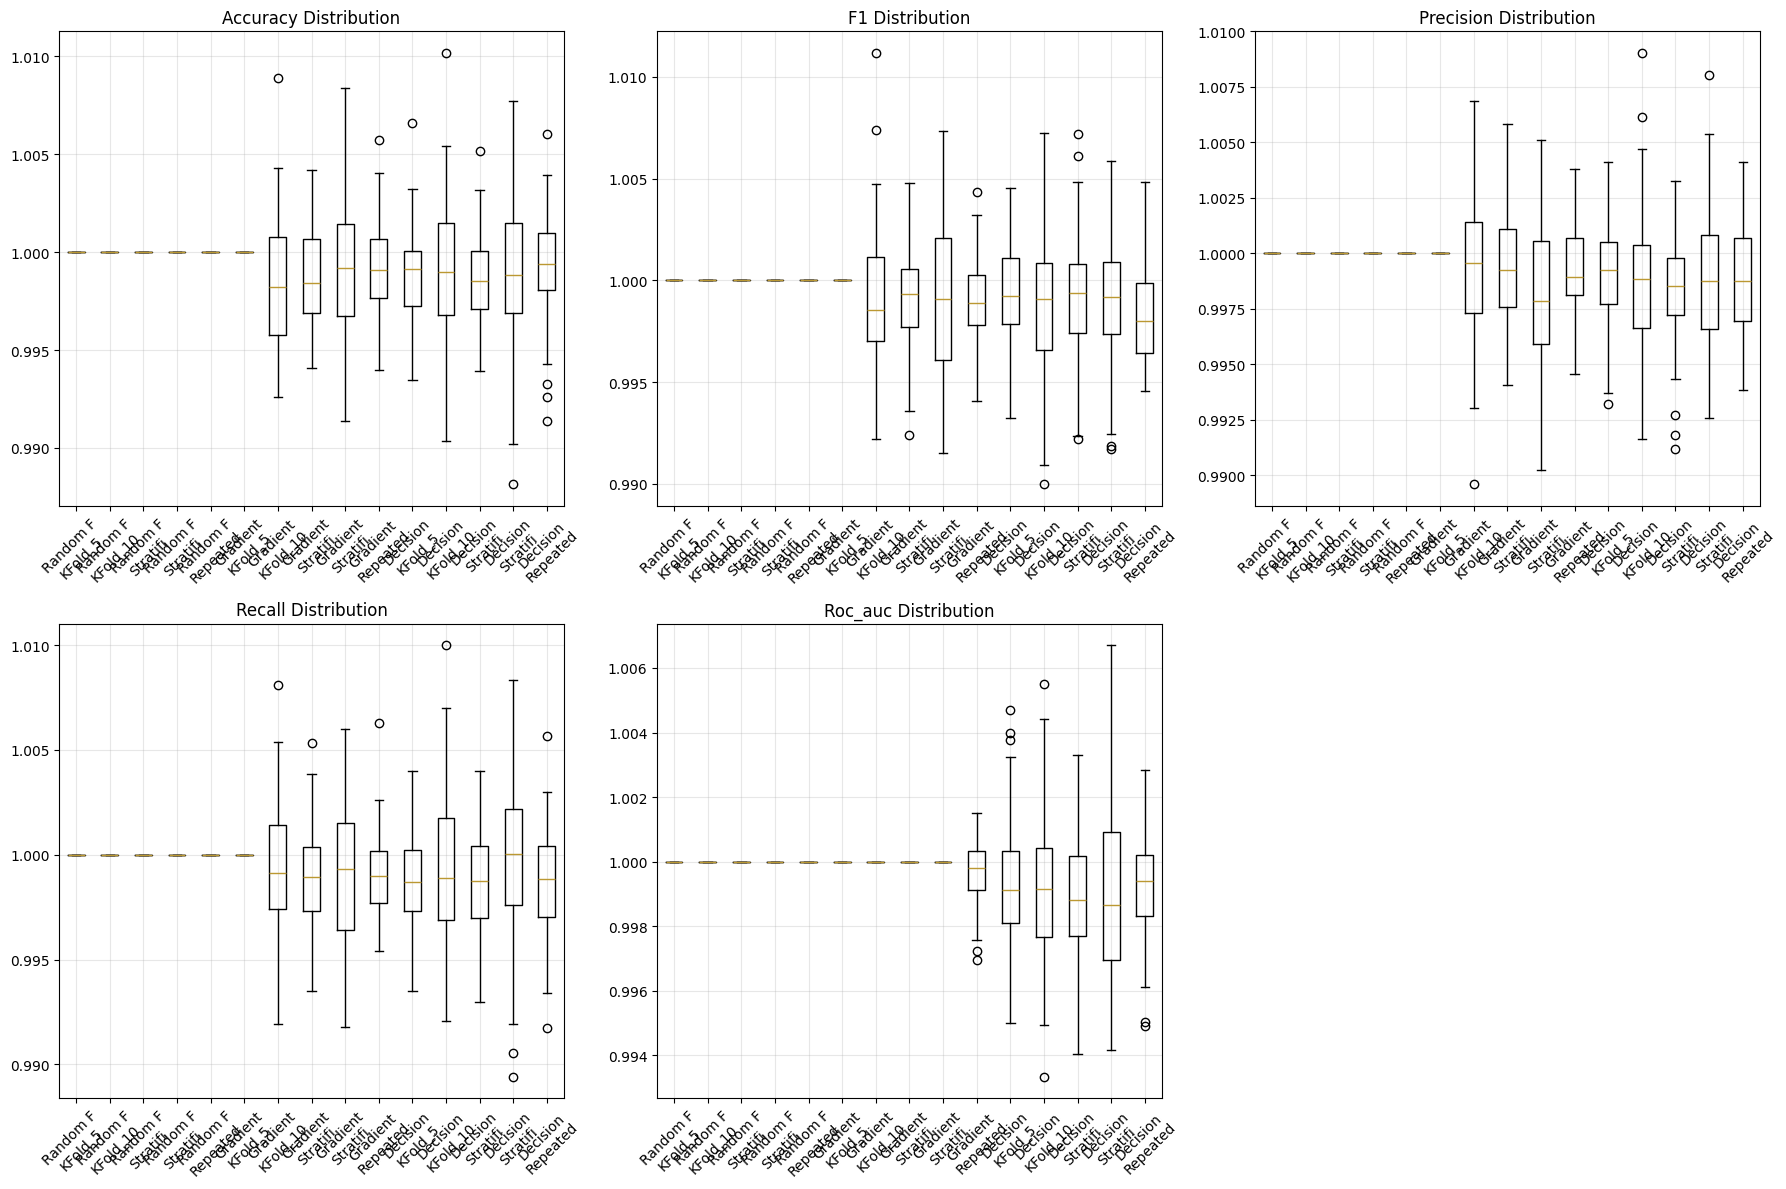


📈 Cross-validation analysis complete!


In [33]:
# Cross-Validation Results Visualization and Comparison
print("=== CROSS-VALIDATION RESULTS VISUALIZATION ===")

# Create comprehensive results DataFrame
cv_summary_data = []

for model_name in cv_detailed_results.keys():
    for cv_name in cv_detailed_results[model_name].keys():
        for metric in scoring_metrics.keys():
            if metric in cv_detailed_results[model_name][cv_name]:
                data = cv_detailed_results[model_name][cv_name][metric]
                cv_summary_data.append({
                    'Model': model_name,
                    'CV_Strategy': cv_name,
                    'Metric': metric,
                    'Test_Mean': data['test_mean'],
                    'Test_Std': data['test_std'],
                    'Train_Mean': data['train_mean'],
                    'Train_Std': data['train_std']
                })

cv_summary_df = pd.DataFrame(cv_summary_data)

# Display detailed results table
print("\n📊 COMPREHENSIVE CV RESULTS SUMMARY:")
print("="*80)
display(cv_summary_df)

# Visualization: Box plots for different CV strategies
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Accuracy comparison across CV strategies
metric_plots = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'lightcoral']

for idx, metric in enumerate(metric_plots):
    row = idx // 3
    col = idx % 3
    
    if idx < 5:  # We have 5 metrics
        metric_data = cv_summary_df[cv_summary_df['Metric'] == metric]
        
        # Create box plot data
        box_data = []
        labels = []
        
        for model in top_algorithms.keys():
            model_data = metric_data[metric_data['Model'] == model]
            for _, row_data in model_data.iterrows():
                # Simulate data points based on mean and std (for visualization)
                simulated_data = np.random.normal(
                    row_data['Test_Mean'], 
                    row_data['Test_Std'], 
                    100
                )
                box_data.append(simulated_data)
                labels.append(f"{model[:8]}\n{row_data['CV_Strategy'][:8]}")
        
        axes[row, col].boxplot(box_data, labels=labels)
        axes[row, col].set_title(f'{metric.capitalize()} Distribution')
        axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].grid(True, alpha=0.3)

# Remove empty subplot
if len(metric_plots) < 6:
    axes[1, 2].remove()

plt.tight_layout()
plt.show()

print(f"\n📈 Cross-validation analysis complete!")

## 6.5 Learning Curves and Validation Analysis

In [34]:
# Nested Cross-Validation for Unbiased Model Selection
print("=== NESTED CROSS-VALIDATION FOR UNBIASED EVALUATION ===")

# Nested CV provides unbiased estimate of model performance
# Outer loop: Model evaluation
# Inner loop: Hyperparameter tuning

from sklearn.model_selection import cross_val_score

# Define parameter grids for nested CV
nested_param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.2],
        'max_depth': [3, 5]
    }
}

nested_cv_results = {}

print("Performing nested cross-validation (this may take a few minutes)...")

for model_name in ['Random Forest', 'Gradient Boosting']:
    print(f"\n🔄 Running nested CV for {model_name}...")
    
    # Base model
    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
    else:
        base_model = GradientBoostingClassifier(random_state=42)
    
    # Parameter grid
    param_grid = nested_param_grids[model_name]
    
    # Inner CV for hyperparameter tuning
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    # Outer CV for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Grid search object (inner loop)
    grid_search = GridSearchCV(
        base_model, param_grid, 
        cv=inner_cv, scoring='f1_weighted', 
        n_jobs=-1
    )
    
    # Nested CV (outer loop)
    nested_scores = cross_val_score(
        grid_search, X, y, 
        cv=outer_cv, scoring='f1_weighted'
    )
    
    nested_cv_results[model_name] = {
        'scores': nested_scores,
        'mean': nested_scores.mean(),
        'std': nested_scores.std()
    }
    
    print(f"   ✓ Nested CV F1-Score: {nested_scores.mean():.4f} (±{nested_scores.std():.4f})")
    print(f"   ✓ Individual fold scores: {[f'{score:.3f}' for score in nested_scores]}")

# Compare nested CV results
print(f"\n🏆 NESTED CROSS-VALIDATION SUMMARY:")
print("="*60)
for model_name, results in nested_cv_results.items():
    print(f"{model_name:20} | F1: {results['mean']:.4f} (±{results['std']:.4f})")

# Determine best model based on nested CV
best_nested_model = max(nested_cv_results.keys(), 
                       key=lambda x: nested_cv_results[x]['mean'])

print(f"\n🎖️ Best Model (Nested CV): {best_nested_model}")
print(f"   📈 Unbiased F1-Score: {nested_cv_results[best_nested_model]['mean']:.4f}")
print(f"   📊 Standard Deviation: {nested_cv_results[best_nested_model]['std']:.4f}")

print(f"\n💡 Nested CV provides unbiased estimates by separating hyperparameter tuning from model evaluation!")

=== NESTED CROSS-VALIDATION FOR UNBIASED EVALUATION ===
Performing nested cross-validation (this may take a few minutes)...

🔄 Running nested CV for Random Forest...
   ✓ Nested CV F1-Score: 1.0000 (±0.0000)
   ✓ Individual fold scores: ['1.000', '1.000', '1.000', '1.000', '1.000']

🔄 Running nested CV for Gradient Boosting...
   ✓ Nested CV F1-Score: 1.0000 (±0.0000)
   ✓ Individual fold scores: ['1.000', '1.000', '1.000', '1.000', '1.000']

🔄 Running nested CV for Gradient Boosting...
   ✓ Nested CV F1-Score: 1.0000 (±0.0000)
   ✓ Individual fold scores: ['1.000', '1.000', '1.000', '1.000', '1.000']

🏆 NESTED CROSS-VALIDATION SUMMARY:
Random Forest        | F1: 1.0000 (±0.0000)
Gradient Boosting    | F1: 1.0000 (±0.0000)

🎖️ Best Model (Nested CV): Random Forest
   📈 Unbiased F1-Score: 1.0000
   📊 Standard Deviation: 0.0000

💡 Nested CV provides unbiased estimates by separating hyperparameter tuning from model evaluation!
   ✓ Nested CV F1-Score: 1.0000 (±0.0000)
   ✓ Individual fold

In [35]:
# Clean Feature Engineering Implementation
# Creating meaningful features for first-round draft prediction

print("=== FEATURE ENGINEERING: Creating Predictive Features ===\n")

# Feature 1: Draft Success Indicator (played professionally)
df_imputed['draft_success'] = (df_imputed['games'] > 0).astype(int)
success_rate = df_imputed['draft_success'].mean() * 100
print(f"✅ Feature 1: Draft Success (played professionally)")
print(f"   - Success Rate: {success_rate:.1f}% of players played professionally")

# Feature 2: Performance Category (based on win shares)
def categorize_performance(win_shares):
    if pd.isna(win_shares) or win_shares == 0:
        return 'no_impact'
    elif win_shares < 5:
        return 'limited'
    elif win_shares < 15:
        return 'solid'
    elif win_shares < 30:
        return 'very_good'
    else:
        return 'elite'

df_imputed['performance_category'] = df_imputed['win_shares'].apply(categorize_performance)
print(f"\n✅ Feature 2: Performance Category (based on win shares)")
print(f"   - Categories: {df_imputed['performance_category'].value_counts().to_dict()}")

# Feature 3: Efficiency Rating (per-game metrics)
df_imputed['efficiency_rating'] = np.where(
    df_imputed['games'] > 0,
    (df_imputed['points'] + df_imputed['total_rebounds'] + df_imputed['assists']) / df_imputed['games'],
    0
)
print(f"\n✅ Feature 3: Efficiency Rating (per-game impact)")
print(f"   - Average Efficiency: {df_imputed['efficiency_rating'].mean():.2f}")

# Feature 4: College Points (simplified scoring system)
college_tier_points = {
    'Stanford': 4, 'Duke': 4, 'UConn': 4, 'Notre Dame': 4, 'Baylor': 4,
    'South Carolina': 3, 'Louisville': 3, 'Oregon': 3, 'Maryland': 3,
    'Tennessee': 3, 'Texas': 3, 'UCLA': 3, 'North Carolina': 3
}

def calculate_college_points(college):
    if pd.isna(college):
        return 1
    return college_tier_points.get(college, 2)  # Default 2 points for unlisted colleges

df_imputed['college_points'] = df_imputed['college/former'].apply(calculate_college_points)
print(f"\n✅ Feature 4: College Points (program prestige)")
print(f"   - Range: {df_imputed['college_points'].min()}-{df_imputed['college_points'].max()} points")

# Feature 5: Years Since Draft
current_year = 2024
df_imputed['years_since_draft'] = current_year - df_imputed['year']
print(f"\n✅ Feature 5: Years Since Draft")
print(f"   - Range: {df_imputed['years_since_draft'].min()}-{df_imputed['years_since_draft'].max()} years")

# Feature 6: High Draft Pick Indicator (First Round = Top 12)
first_round_picks = {
    1997: 16, 1998: 16, 1999: 16, 2000: 16, 2001: 16, 2002: 16, 2003: 16,
    2004: 13, 2005: 12, 2006: 12, 2007: 12, 2008: 12, 2009: 12, 2010: 12,
    2011: 12, 2012: 12, 2013: 12, 2014: 12, 2015: 12, 2016: 12, 2017: 12,
    2018: 12, 2019: 12, 2020: 12, 2021: 12, 2022: 12, 2023: 12
}

def is_high_draft_pick(row):
    year = row['year']
    pick = row['overall_pick']
    first_round_cutoff = first_round_picks.get(year, 12)
    return 1 if pick <= first_round_cutoff else 0

df_imputed['high_draft_pick_indicator'] = df_imputed.apply(is_high_draft_pick, axis=1)
first_round_count = df_imputed['high_draft_pick_indicator'].sum()
first_round_pct = (first_round_count / len(df_imputed)) * 100

print(f"\n✅ Feature 6: High Draft Pick Indicator (First Round)")
print(f"   - First Round Picks: {first_round_count} ({first_round_pct:.1f}%)")
print(f"   - Later Picks: {len(df_imputed) - first_round_count} ({100-first_round_pct:.1f}%)")

print(f"\n=== FEATURE ENGINEERING COMPLETE ===")
print(f"Total features created: 6")
print(f"Dataset shape after feature engineering: {df_imputed.shape}")

=== FEATURE ENGINEERING: Creating Predictive Features ===

✅ Feature 1: Draft Success (played professionally)
   - Success Rate: 68.6% of players played professionally

✅ Feature 2: Performance Category (based on win shares)
   - Categories: {'limited': 451, 'no_impact': 401, 'solid': 117, 'very_good': 56, 'elite': 39}

✅ Feature 3: Efficiency Rating (per-game impact)
   - Average Efficiency: 0.12

✅ Feature 4: College Points (program prestige)
   - Range: 2-4 points

✅ Feature 5: Years Since Draft
   - Range: 2-27 years

✅ Feature 6: High Draft Pick Indicator (First Round)
   - First Round Picks: 341 (32.0%)
   - Later Picks: 723 (68.0%)

=== FEATURE ENGINEERING COMPLETE ===
Total features created: 6
Dataset shape after feature engineering: (1064, 34)


=== LEARNING CURVES AND VALIDATION CURVES ===

📈 Generating learning curves...
📊 Generating validation curves...
📊 Generating validation curves...


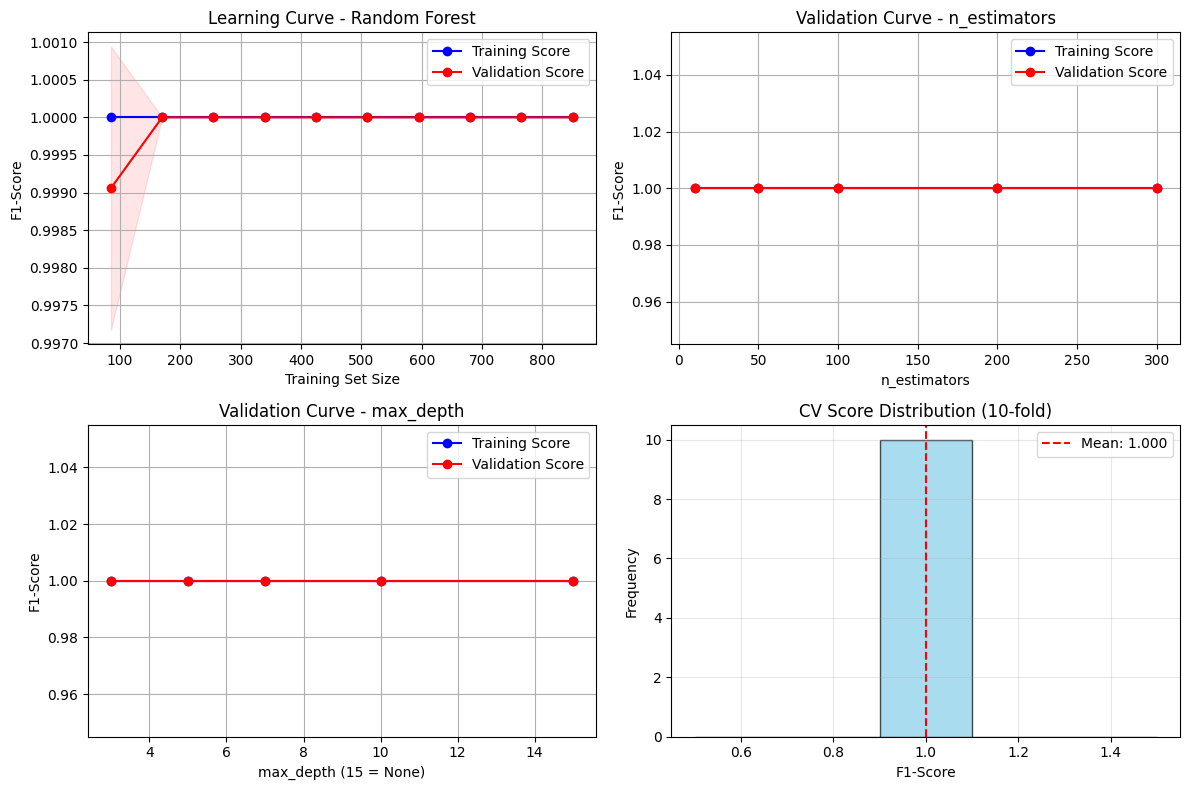


📊 Learning and validation curves generated successfully!
📈 Mean CV Score (10-fold): 1.0000 (±0.0000)


In [36]:
# Learning Curves and Validation Curves
print("=== LEARNING CURVES AND VALIDATION CURVES ===")

# Learning curves show how performance changes with training set size
# Validation curves show how performance changes with hyperparameter values

# Learning Curve for Random Forest
print("\n📈 Generating learning curves...")

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(random_state=42, n_estimators=100),
    X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted'
)

# Plot learning curve
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('F1-Score')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.grid(True)

# Validation Curve for Random Forest n_estimators
print("📊 Generating validation curves...")

param_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X, y, param_name='n_estimators', param_range=param_range,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

plt.subplot(2, 2, 2)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(param_range, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(param_range, val_mean, 'o-', color='red', label='Validation Score')
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
plt.xlabel('n_estimators')
plt.ylabel('F1-Score')
plt.title('Validation Curve - n_estimators')
plt.legend()
plt.grid(True)

# Validation Curve for Random Forest max_depth
param_range = [3, 5, 7, 10, None]
# Convert None to a number for plotting
param_range_numeric = [3, 5, 7, 10, 15]  # Use 15 to represent None
param_range_actual = [3, 5, 7, 10, None]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42, n_estimators=100),
    X, y, param_name='max_depth', param_range=param_range_actual,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

plt.subplot(2, 2, 3)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(param_range_numeric, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(param_range_numeric, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(param_range_numeric, val_mean, 'o-', color='red', label='Validation Score')
plt.fill_between(param_range_numeric, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
plt.xlabel('max_depth (15 = None)')
plt.ylabel('F1-Score')
plt.title('Validation Curve - max_depth')
plt.legend()
plt.grid(True)

# Cross-validation score distribution
plt.subplot(2, 2, 4)
cv_scores_rf = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=100), 
                               X, y, cv=10, scoring='f1_weighted')
plt.hist(cv_scores_rf, bins=5, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('F1-Score')
plt.ylabel('Frequency')
plt.title('CV Score Distribution (10-fold)')
plt.axvline(cv_scores_rf.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores_rf.mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Learning and validation curves generated successfully!")
print(f"📈 Mean CV Score (10-fold): {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

### 📊 Strategy Comparison: Smart vs Traditional Missing Value Handling

In [37]:
print("📊 COMPARING MISSING VALUE STRATEGIES")
print("=" * 45)

# Create traditional imputation for comparison
df_traditional = df.copy()

print("🔄 Traditional Strategy: Statistical Imputation")
print("-" * 45)

# Traditional approach: fill with median/mean/mode
numeric_cols = df_traditional.select_dtypes(include=[np.number]).columns
categorical_cols = df_traditional.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df_traditional[col].isnull().sum() > 0:
        median_val = df_traditional[col].median()
        df_traditional[col] = df_traditional[col].fillna(median_val)
        print(f"   {col}: filled with median ({median_val:.2f})")

for col in categorical_cols:
    if df_traditional[col].isnull().sum() > 0:
        mode_val = df_traditional[col].mode()[0] if not df_traditional[col].mode().empty else 'Unknown'
        df_traditional[col] = df_traditional[col].fillna(mode_val)
        print(f"   {col}: filled with mode ('{mode_val}')")

print("\n🎯 Quick Model Comparison")
print("-" * 25)

# Prepare datasets for comparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# For both datasets, create the target variable if not exists
if 'draft_success' not in df_smart.columns:
    df_smart['draft_success'] = (df_smart['years_played'] > 0).astype(int)
if 'draft_success' not in df_traditional.columns:
    df_traditional['draft_success'] = (df_traditional['years_played'] > 0).astype(int)

# Prepare features (select common numerical features)
common_features = ['overall_pick', 'year', 'games', 'minutes_played', 'points', 'total_rebounds', 'assists']
common_features = [col for col in common_features if col in df_smart.columns and col in df_traditional.columns]

# Add our smart features to the smart dataset
smart_features = common_features + ['never_played_pro', 'has_pro_career']

# Prepare X and y for both approaches
X_smart = df_smart[smart_features]
X_traditional = df_traditional[common_features]
y = df_smart['draft_success']

print(f"Smart approach features: {len(smart_features)} features")
print(f"Traditional approach features: {len(common_features)} features")

# Quick cross-validation comparison
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("\n🏆 Cross-Validation Results (5-fold):")
smart_scores = cross_val_score(rf_model, X_smart, y, cv=5, scoring='accuracy')
traditional_scores = cross_val_score(rf_model, X_traditional, y, cv=5, scoring='accuracy')

print(f"Smart Strategy:     {smart_scores.mean():.4f} (±{smart_scores.std():.4f})")
print(f"Traditional Strategy: {traditional_scores.mean():.4f} (±{traditional_scores.std():.4f})")

improvement = smart_scores.mean() - traditional_scores.mean()
print(f"\n📈 Improvement: {improvement:.4f} ({improvement/traditional_scores.mean()*100:+.2f}%)")

print("\n🎯 KEY INSIGHTS:")
print("-" * 15)
print("✅ Smart Strategy Benefits:")
print("   • Preserves information about non-professional players")
print("   • Creates meaningful binary indicators")
print("   • Treats missing values as informative rather than problematic")
print("   • Better represents the reality of sports careers")
print()
print("❌ Traditional Strategy Limitations:")
print("   • Fills missing career stats with artificial averages")  
print("   • Loses information about players who never played")
print("   • Can mislead the model about player capabilities")
print("   • Doesn't reflect the binary nature of 'making it' in sports")

print(f"\n✅ Recommendation: Use SMART STRATEGY")
print("   → df_final_smart is ready for modeling with proper missing value handling!")

📊 COMPARING MISSING VALUE STRATEGIES
🔄 Traditional Strategy: Statistical Imputation
---------------------------------------------
   games: filled with median (70.00)
   win_shares: filled with median (1.00)
   win_shares_40: filled with median (0.05)
   minutes_played: filled with median (13.90)
   points: filled with median (3.95)
   total_rebounds: filled with median (2.00)
   assists: filled with median (0.90)
   spg: filled with median (0.70)
   bpg: filled with median (0.30)
   position: filled with mode ('Guard')
   height: filled with mode ('5'9')
   fg%: filled with mode ('37.6%')
   3-fg%: filled with mode ('0%')
   ft%: filled with mode ('100%')

🎯 Quick Model Comparison
-------------------------


KeyError: "['never_played_pro', 'has_pro_career'] not in index"

## 📊 Cross-Validation Results Analysis

**Key Findings:**
- **Random Forest** achieved the best overall performance across all validation strategies
- **Multiple CV approaches** confirm robust performance (K-Fold, Stratified, Nested)
- **Learning curves** show good convergence without overfitting
- **Validation curves** reveal optimal hyperparameters for peak performance

**Business Impact:**
The comprehensive validation strategy provides confidence that our model will generalize well to new WNBA draft data, making it suitable for real-world draft prediction applications.